In [16]:
import glob
import pandas as pd
import numpy as np
import os
import re

# 1. 파일명 파싱 정규식
filename_re = re.compile(
    r"^Mux_"
    r"(?P<map>\w+)_"
    r"WS(?P<ws>[\d\.]+)_"
    r"WT(?P<wt>[\d\.]+)_"
    r"WC(?P<wc>[\d\.]+)_"
    r"WCL(?P<wcl>[\d\.]+)_"
    r"WD(?P<wd>[\d\.]+)_"
    r"DM(?P<dm>[\d\.]+)_"
    r"(?P<opp>.*?)_"
    r"(?P<mode>MUX_RACING)_"
    r"(?P<stamp>\d+)_"
    r"(?P<result>\w+)_"
    r"dur_(?P<dur>[\d\.]+)s\.csv$"
)

def parse_filename(path):
    fname = os.path.basename(path)
    m = filename_re.match(fname)
    if not m:
        # 파일 형식이 다를 경우 경고 후 None 반환 혹은 예외 처리
        return None
    
    d = m.groupdict()
    return {
        "map": d["map"],
        "ws": float(d["ws"]),
        "wt": float(d["wt"]),
        "wc": float(d["wc"]),
        "wcl": float(d["wcl"]),
        "wd": float(d["wd"]),
        "dm": float(d["dm"]),
        "opp_config": d["opp"],
        "mode": d["mode"],
        "stamp": int(d["stamp"]),
        "file_result": d["result"],
        "file_dur": float(d["dur"]),
        "filename": fname,
    }

def split_timeseries_and_summary(df):
    """
    CSV의 상단 시계열 데이터(ts)와 하단 요약 데이터(summary)를 분리합니다.
    """
    # 't' 컬럼이 숫자인 행만 시계열로 간주
    ts_mask = pd.to_numeric(df["t"], errors="coerce").notna()
    
    ts = df[ts_mask].copy()
    ts["t"] = ts["t"].astype(float)
    
    # 숫자형으로 변환할 주요 컬럼들
    num_cols = [
        "x", "y", "yaw", "speed", "yaw_rate", "a_lat", 
        "min_d", "track_error", "collision",
        "fre_min_d", "fgm_min_d", "fre_track", "fgm_track"
    ]
    for c in num_cols:
        if c in ts.columns:
            ts[c] = pd.to_numeric(ts[c], errors="coerce")
            
    summary = df[~ts_mask].copy()
    return ts, summary

def get_summary_value(summary, label, to_float=True):
    """
    요약 섹션에서 특정 라벨(Label)에 해당하는 값(Value)을 가져옵니다.
    CSV 구조상 Label은 't' 컬럼에, Value는 'x' 컬럼에 위치한다고 가정합니다.
    """
    if summary.empty:
        return np.nan
    
    # Label이 일치하는 행 찾기
    row = summary[summary["t"] == label]
    if row.empty:
        return np.nan
    
    val = row["x"].iloc[0]
    
    if to_float:
        try:
            return float(val)
        except:
            return np.nan
    return str(val).strip()

def compute_total_distance(ts):
    dx = ts["x"].diff()
    dy = ts["y"].diff()
    dist = np.hypot(dx, dy)
    return float(dist.fillna(0).sum())

# %% 메인 처리 로직
records = []
# 실제 파일 경로 패턴 입력 (예: "./logs/*.csv")
# PATTERN = "./*.csv" 

for path in glob.glob("./logs/mux/*.csv"):
    try:
        # 1. 파일명 파싱
        meta = parse_filename(path)
        if meta is None:
            print(f"Skipping file (format mismatch): {path}")
            continue

        # 2. 데이터 로드 및 분리
        df = pd.read_csv(path)
        ts, summary = split_timeseries_and_summary(df)

        # ---------------------------------------------------------
        # 3. Summary 섹션 데이터 추출 (제공해주신 리스트 기반)
        # ---------------------------------------------------------
        # 기본 정보
        finish_reason = get_summary_value(summary, "Finish Reason", to_float=False)
        duration_s    = get_summary_value(summary, "Duration (s)", to_float=True)
        total_dist_m  = get_summary_value(summary, "Total Dist (m)", to_float=True)
        collision_str = get_summary_value(summary, "Collision", to_float=False)
        
        # 주행 통계
        max_speed     = get_summary_value(summary, "Max Speed (m/s)", to_float=True)
        max_lat_acc   = get_summary_value(summary, "Max Lat Acc (m/s^2)", to_float=True)
        
        # Global(전체) 통계
        global_min_d      = get_summary_value(summary, "Global Min Dist (m)", to_float=True)
        global_unsafe_r   = get_summary_value(summary, "Global Unsafe Ratio", to_float=True)
        global_track_rms  = get_summary_value(summary, "Global Track RMS (m)", to_float=True)
        global_lat_acc_rms= get_summary_value(summary, "Global Lat Acc RMS", to_float=True)
        
        # FGM / FRENET 사용률 및 통계
        frenet_usage_pct = get_summary_value(summary, "FRENET Usage (%)", to_float=True)
        fgm_usage_pct    = get_summary_value(summary, "FGM Usage (%)", to_float=True)
        
        fgm_min_d        = get_summary_value(summary, "FGM Min Dist (m)", to_float=True)
        fgm_unsafe_r     = get_summary_value(summary, "FGM Unsafe Ratio", to_float=True)
        fgm_track_rms    = get_summary_value(summary, "FGM Track RMS (m)", to_float=True)

        # ---------------------------------------------------------
        # 4. TS 데이터 기반 보완 (Summary에 없는 정보 계산)
        # ---------------------------------------------------------
        if not ts.empty:
            # 거리 계산 (Summary에 없으면)
            if np.isnan(total_dist_m):
                total_dist_m = compute_total_distance(ts)
            
            # 충돌 여부 (Summary 텍스트 -> TS 데이터 순으로 확인)
            if isinstance(collision_str, str):
                collision_flag = (collision_str.upper() == "YES")
            elif "collision" in ts.columns:
                collision_flag = (ts["collision"].max() > 0)
            else:
                collision_flag = False

            # [중요] FRENET 관련 통계는 Summary에 없을 수 있으므로 TS에서 계산
            # fre_min_d 평균/최소
            if "fre_min_d" in ts.columns:
                fre_min_d_mean = ts["fre_min_d"].mean()
                fre_min_d_min  = ts["fre_min_d"].min()
            else:
                fre_min_d_mean = np.nan
                fre_min_d_min  = np.nan
                
            # fre_track 평균 (Track Error)
            if "fre_track" in ts.columns:
                fre_track_rms_calc = np.sqrt((ts["fre_track"]**2).mean()) # RMS 계산
            else:
                fre_track_rms_calc = np.nan

            ts_last_t = float(ts["t"].iloc[-1])
        else:
            collision_flag = False
            ts_last_t = np.nan
            fre_min_d_mean, fre_min_d_min, fre_track_rms_calc = np.nan, np.nan, np.nan

        # ---------------------------------------------------------
        # 5. 최종 데이터 병합
        # ---------------------------------------------------------
        # Lap Time 우선순위: Summary Duration -> 파일명 Duration -> TS 마지막 시간
        lap_time = duration_s
        if np.isnan(lap_time):
            lap_time = meta["file_dur"]
        if np.isnan(lap_time):
            lap_time = ts_last_t
        
        # 성공 여부 (파일명 기준)
        is_success = (meta["file_result"].upper() == "GOAL")

        record = {
            **meta,  # 파일명 파싱 정보 (WS, WT, WC 등)
            
            # --- Summary 추출 데이터 ---
            "finish_reason": finish_reason,
            "duration_s": lap_time,
            "total_dist_m": total_dist_m,
            "collision_flag": collision_flag,
            "max_speed": max_speed,
            "max_lat_acc": max_lat_acc,
            
            "global_min_d": global_min_d,
            "global_unsafe_ratio": global_unsafe_r,
            "global_track_rms": global_track_rms,
            "global_lat_acc_rms": global_lat_acc_rms,
            
            "frenet_usage_pct": frenet_usage_pct,
            "fgm_usage_pct": fgm_usage_pct,
            
            "fgm_min_d": fgm_min_d,
            "fgm_unsafe_ratio": fgm_unsafe_r,
            "fgm_track_rms": fgm_track_rms,
            
            # --- TS 계산 데이터 (보완용) ---
            "fre_min_d_mean": fre_min_d_mean, # Frenet 평균 거리
            "fre_min_d_min": fre_min_d_min,   # Frenet 최소 거리 (위험도)
            "fre_track_rms_calc": fre_track_rms_calc, # Frenet 트랙 에러 RMS
            
            "ts_last_t": ts_last_t,
            "is_success": is_success
        }
        
        records.append(record)
        
    except Exception as e:
        print(f"Error processing {path}: {e}")

# 결과 확인 (DataFrame 변환)
res_df = pd.DataFrame(records)
print(f"Processed {len(res_df)} files.")
if not res_df.empty:
    print(res_df.head())

Skipping file (format mismatch): ./logs/mux\Mux_playground_WS1.44_WT2.51_WC1.72_WCL2.55_WD2.78_DM0.55_Opp_bumper_v_5.csv_MUX_OBSTACLE_1765106178_CRASH_dur_9.90s.csv
Skipping file (format mismatch): ./logs/mux\Mux_playground_WS1.37_WT1.91_WC1.19_WCL1.78_WD2.09_DM0.44_Opp_bumper_slow_0.5.csv_MUX_OBSTACLE_1765064530_GOAL_dur_13.13s.csv
Skipping file (format mismatch): ./logs/mux\Mux_playground_WS2.90_WT1.60_WC0.74_WCL1.29_WD1.42_DM0.41_Opp_bumper_v_4.csv_MUX_OBSTACLE_1765102352_GOAL_dur_12.29s.csv
Skipping file (format mismatch): ./logs/mux\Mux_playground_WS1.44_WT1.95_WC1.27_WCL1.93_WD2.26_DM0.46_Opp_bumper_slow_1.5.csv_MUX_OBSTACLE_1765080462_GOAL_dur_14.05s.csv
Skipping file (format mismatch): ./logs/mux\Mux_playground_WS1.44_WT1.95_WC1.27_WCL1.93_WD2.26_DM0.46_Opp_bumper_v_5.csv_MUX_OBSTACLE_1765109100_GOAL_dur_15.05s.csv
Skipping file (format mismatch): ./logs/mux\Mux_playground_WS0.6928_WT1.1848_WC1.3157_WCL2.794_WD2.3887_DM0.2309_Opp_bumper_slow_2.csv_MUX_OBSTACLE_1765055781_GOAL_d

In [11]:
output_filename = f"simulation_summary_mux_speed.csv"

# encoding='utf-8-sig'는 엑셀에서 열었을 때 한글 깨짐을 방지합니다.
res_df.to_csv(output_filename, index=False, encoding='utf-8-sig')


In [22]:
import glob
import pandas as pd
import numpy as np
import os
import re

# -----------------------------------------------------------------------------
# 1. 파일명 파싱 및 유틸리티 함수
# -----------------------------------------------------------------------------
filename_re = re.compile(
    r"^Mux_"
    r"(?P<map>\w+)_"
    r"WS(?P<ws>[\d\.]+)_"
    r"WT(?P<wt>[\d\.]+)_"
    r"WC(?P<wc>[\d\.]+)_"
    r"WCL(?P<wcl>[\d\.]+)_"
    r"WD(?P<wd>[\d\.]+)_"
    r"DM(?P<dm>[\d\.]+)_"
    r"(?P<opp>.*?)_"
    r"(?P<mode>MUX_OBSTACLE)_"
    r"(?P<stamp>\d+)_"
    r"(?P<result>\w+)_"
    r"dur_(?P<dur>[\d\.]+)s\.csv$"
)

def parse_filename(path):
    fname = os.path.basename(path)
    m = filename_re.match(fname)
    if not m:
        return None
    d = m.groupdict()
    return {
        "map": d["map"],
        "ws": float(d["ws"]),
        "wt": float(d["wt"]),
        "wc": float(d["wc"]),
        "wcl": float(d["wcl"]),
        "wd": float(d["wd"]),
        "dm": float(d["dm"]),
        "opp_config": d["opp"],
        "mode": d["mode"],
        "stamp": int(d["stamp"]),
        "file_result": d["result"],
        "file_dur": float(d["dur"]),
        "filename": fname,
    }

def split_timeseries_and_summary(df):
    ts_mask = pd.to_numeric(df["t"], errors="coerce").notna()
    ts = df[ts_mask].copy()
    ts["t"] = ts["t"].astype(float)
    
    # 숫자형 변환 대상 컬럼
    num_cols = [
        "x", "y", "yaw", "speed", "yaw_rate", "a_lat", 
        "min_d", "track_error", "collision",
        "fre_min_d", "fgm_min_d", "fre_track", "fgm_track"
    ]
    for c in num_cols:
        if c in ts.columns:
            ts[c] = pd.to_numeric(ts[c], errors="coerce")
            
    summary = df[~ts_mask].copy()
    return ts, summary

def get_summary_value(summary, label, to_float=True):
    if summary.empty: return np.nan
    row = summary[summary["t"] == label]
    if row.empty: return np.nan
    val = row["x"].iloc[0]
    if to_float:
        try:
            return float(val)
        except:
            return np.nan
    return str(val).strip()

def compute_total_distance(ts):
    dx = ts["x"].diff()
    dy = ts["y"].diff()
    dist = np.hypot(dx, dy)
    return float(dist.fillna(0).sum())

def get_valid_min(series):
    valid_data = series[series > 0.001]
    if valid_data.empty:
        return np.nan
    return valid_data.min()

def get_valid_unsafe_ratio(series, threshold):
    valid_data = series[series > 0.001]
    if valid_data.empty:
        return 0.0
    unsafe_count = (valid_data < threshold).sum()
    return unsafe_count / len(valid_data)

def get_rms(series):
    if series.empty: return np.nan
    return np.sqrt((series**2).mean())

# -----------------------------------------------------------------------------
# 2. 점수 계산 로직 (Calibration 적용됨)
# -----------------------------------------------------------------------------
def calculate_component_score(min_d, unsafe_ratio, track_rms, 
                              d_safe=0.0, 
                              d_good=0.5, 
                              track_rms_bad=2.0, 
                              w_safety=0.6, w_comfort=0.1):
    
    # Safety Score
    if pd.isna(min_d): min_d = 0.0 
    
    if d_good > d_safe:
        Sd = (min_d - d_safe) / (d_good - d_safe)
    else:
        Sd = 1.0
    Sd = max(0.0, min(1.0, Sd))
    
    # Unsafe Ratio Score
    Su = 1.0 - max(0.0, min(1.0, unsafe_ratio))
    
    S_safety = 0.7 * Sd + 0.3 * Su
    
    # Comfort Score
    if pd.isna(track_rms): track_rms = track_rms_bad 
    S_track = 1.0 - max(0.0, min(1.0, track_rms / track_rms_bad))
    S_comfort = S_track
    
    weighted_score = (w_safety * S_safety + w_comfort * S_comfort) / (w_safety + w_comfort)
    return weighted_score

def calculate_progress_score(duration, t_min, t_max):
    if pd.isna(duration) or duration < 1.0: return 0.0
    if pd.isna(t_min) or pd.isna(t_max) or t_max <= t_min: return 1.0
    
    val = (t_max - duration) / (t_max - t_min)
    return max(0.0, min(1.0, val))

# -----------------------------------------------------------------------------
# 3. 메인 처리 로직
# -----------------------------------------------------------------------------
records = []
search_pattern = "./logs/mux/*.csv" # 현재 디렉토리의 모든 csv 대상

UNSAFE_THRESHOLD = 0.1 

for path in glob.glob(search_pattern):
    try:
        # Mux_playground 파일만 대상
        if not os.path.basename(path).startswith("Mux_playground"): continue

        meta = parse_filename(path)
        if meta is None: continue
        
        df = pd.read_csv(path)
        ts, summary = split_timeseries_and_summary(df)

        finish_reason = get_summary_value(summary, "Finish Reason", to_float=False)
        duration_s = get_summary_value(summary, "Duration (s)", to_float=True)
        total_dist_m = get_summary_value(summary, "Total Dist (m)", to_float=True)
        collision_str = get_summary_value(summary, "Collision", to_float=False)
        
        fgm_min_d_val = np.nan
        fgm_unsafe_r_val = 0.0
        fgm_track_rms_val = np.nan
        
        fre_min_d_val = np.nan
        fre_unsafe_r_val = 0.0
        fre_track_rms_val = np.nan
        
        # [NEW] 플래너 비율 초기값
        fgm_ratio = 0.0
        frenet_ratio = 0.0
        
        collision_flag = False
        
        if not ts.empty:
            if np.isnan(total_dist_m): total_dist_m = compute_total_distance(ts)
            
            if isinstance(collision_str, str) and collision_str.upper() == "YES":
                collision_flag = True
            elif "collision" in ts.columns and ts["collision"].max() > 0:
                collision_flag = True

            # [NEW] Planner 비율 계산
            if "planner" in ts.columns:
                # normalize=True로 전체 개수 대비 비율(0~1) 계산
                planner_counts = ts["planner"].value_counts(normalize=True)
                fgm_ratio = planner_counts.get("FGM", 0.0)
                frenet_ratio = planner_counts.get("FRENET", 0.0)

            # FGM Stats
            if "fgm_min_d" in ts.columns:
                fgm_min_d_val = get_valid_min(ts["fgm_min_d"])
                fgm_unsafe_r_val = get_valid_unsafe_ratio(ts["fgm_min_d"], UNSAFE_THRESHOLD)
            if "fgm_track" in ts.columns:
                fgm_track_rms_val = get_rms(ts["fgm_track"])

            # Frenet Stats
            if "fre_min_d" in ts.columns:
                fre_min_d_val = get_valid_min(ts["fre_min_d"])
                fre_unsafe_r_val = get_valid_unsafe_ratio(ts["fre_min_d"], UNSAFE_THRESHOLD)
            if "fre_track" in ts.columns:
                fre_track_rms_val = get_rms(ts["fre_track"])

            ts_last_t = float(ts["t"].iloc[-1])
        else:
            ts_last_t = np.nan

        lap_time = duration_s
        if np.isnan(lap_time): lap_time = meta["file_dur"]
        if np.isnan(lap_time): lap_time = ts_last_t

        records.append({
            **meta,
            "finish_reason": finish_reason,
            "duration_s": lap_time,
            "total_dist_m": total_dist_m,
            "collision_flag": collision_flag,
            "fgm_min_d": fgm_min_d_val,
            "fgm_unsafe_ratio": fgm_unsafe_r_val,
            "fgm_track_rms": fgm_track_rms_val,
            "fre_min_d": fre_min_d_val,
            "fre_unsafe_ratio": fre_unsafe_r_val,
            "fre_track_rms": fre_track_rms_val,
            # [NEW] 비율 정보 추가
            "fgm_ratio": fgm_ratio,
            "frenet_ratio": frenet_ratio
        })
        
    except Exception as e:
        print(f"Error processing {path}: {e}")

# 점수 계산 및 집계
df_raw = pd.DataFrame(records)

if not df_raw.empty:
    w_safety = 0.6
    w_comfort = 0.1
    w_progress = 0.3
    
    # Component Scores
    df_raw["fgm_sc"] = df_raw.apply(
        lambda r: calculate_component_score(r["fgm_min_d"], r["fgm_unsafe_ratio"], r["fgm_track_rms"]), 
        axis=1
    )
    df_raw["fre_sc"] = df_raw.apply(
        lambda r: calculate_component_score(r["fre_min_d"], r["fre_unsafe_ratio"], r["fre_track_rms"]), 
        axis=1
    )
    
    # Progress Score
    valid_runs = df_raw[(df_raw["collision_flag"]==False) & (df_raw["file_result"]=="GOAL")]
    if not valid_runs.empty:
        t_min = valid_runs["duration_s"].min()
        t_max = valid_runs["duration_s"].max()
    else:
        t_min, t_max = np.nan, np.nan
        
    df_raw["S_progress"] = df_raw["duration_s"].apply(lambda d: calculate_progress_score(d, t_min, t_max))
    
    def finalize_score(row, sc_val):
        if row["collision_flag"] or row["file_result"] != "GOAL": 
            return 0.0
        score = (sc_val * (w_safety + w_comfort)) + (row["S_progress"] * w_progress)
        return score * 100.0

    df_raw["Score_FGM"] = df_raw.apply(lambda r: finalize_score(r, r["fgm_sc"]), axis=1)
    df_raw["Score_FRENET"] = df_raw.apply(lambda r: finalize_score(r, r["fre_sc"]), axis=1)
    
    # [수정] 집계 (비율 평균 추가)
    param_keys = ["ws", "wt", "wc", "wcl", "wd", "dm"]
    agg_funcs = {
        "Score_FGM": ["mean", "max"],
        "Score_FRENET": ["mean", "max"],
        "duration_s": "mean",
        "collision_flag": "sum",
        "fgm_min_d": "mean",
        "fre_min_d": "mean",
        # [NEW] 비율 평균 추가
        "fgm_ratio": "mean",
        "frenet_ratio": "mean"
    }
    
    df_grouped = df_raw.groupby(param_keys).agg(agg_funcs).reset_index()
    df_grouped.columns = ['_'.join(col).strip() if col[1] else col[0] for col in df_grouped.columns.values]
    df_grouped = df_grouped.sort_values(by="Score_FGM_mean", ascending=False)
    
    # 저장
    df_raw.to_csv("simulation_results_scored_calibrated_v2.csv", index=False, encoding="utf-8-sig")
    df_grouped.to_csv("parameter_analysis_calibrated_v2.csv", index=False, encoding="utf-8-sig")
    
    print("분석 완료! 결과 파일이 생성되었습니다.")
    print("\n=== Top 5 Parameters (with Planner Ratios) ===")
    print(df_grouped[['ws', 'wt', 'Score_FGM_mean', 'fgm_ratio_mean', 'frenet_ratio_mean']].head())
else:
    print("처리할 데이터가 없습니다.")

분석 완료! 결과 파일이 생성되었습니다.

=== Top 5 Parameters (with Planner Ratios) ===
       ws    wt  Score_FGM_mean  fgm_ratio_mean  frenet_ratio_mean
76   0.93  2.02       34.849392        0.294904           0.705096
90   0.99  2.18       34.484444        0.255224           0.744776
173  1.50  2.47       34.443281        0.262642           0.737358
223  1.75  1.60       34.402924        0.367387           0.632613
103  1.12  2.38       34.376722        0.289831           0.710169


In [23]:
mux_avoid_raw = df_raw
mux_avoid_group=df_grouped
mux_race = res_df

In [70]:
mux_avoid_group

,ws,wt,wc,wcl,wd,dm,Score_FGM_mean,Score_FGM_max,Score_FRENET_mean,Score_FRENET_max,duration_s_mean,collision_flag_sum,fgm_min_d_mean,fre_min_d_mean,fgm_ratio_mean,frenet_ratio_mean
76,0.9300,2.0200,1.3600,2.2000,2.4600,0.4800,34.849392,38.580269,31.470567,33.560821,13.64875,0,0.002829,0.008326,0.294904,0.705096
90,0.9900,2.1800,1.4700,2.3300,2.6300,0.5400,34.484444,38.546240,31.427791,35.647358,13.60875,0,0.004934,0.007547,0.255224,0.744776
173,1.5000,2.4700,1.6900,2.5600,2.8200,0.5800,34.443281,39.939051,31.089140,32.979911,13.73375,0,0.003750,0.007781,0.262642,0.737358
223,1.7500,1.6000,0.9800,1.3200,0.5300,0.4700,34.402924,37.801933,35.589440,37.419562,11.72500,0,0.003632,0.017816,0.367387,0.632613
103,1.1200,2.3800,1.6600,2.4400,2.8000,0.5400,34.376722,37.927877,31.263158,35.161952,13.52500,0,0.004287,0.007953,0.289831,0.710169
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
301,2.7608,1.1883,0.5954,0.3531,0.7395,0.1251,7.981973,32.396438,8.560268,37.171846,9.53125,5,0.010730,0.015169,0.226170,0.773830
120,1.2497,2.4833,1.4393,1.4940,1.5434,0.2193,7.655295,31.117325,7.507518,30.334874,8.60375,4,0.014460,0.023908,0.271214,0.603786
233,1.9219,2.1553,1.3408,1.8841,1.3669,0.1919,7.379797,33.269876,7.281675,35.278923,8.74500,4,0.016393,0.016549,0.309347,0.565653
246,2.1567,1.3737,0.6980,0.8333,0.9677,0.1378,7.190681,29.353823,7.879364,34.103224,8.18500,4,0.016549,0.020892,0.160748,0.714252


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_28132\1466100619.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='fgm_group', y='is_success', data=df, ax=axes[0], palette=['#e74c3c', '#2ecc71'], errorbar=None)


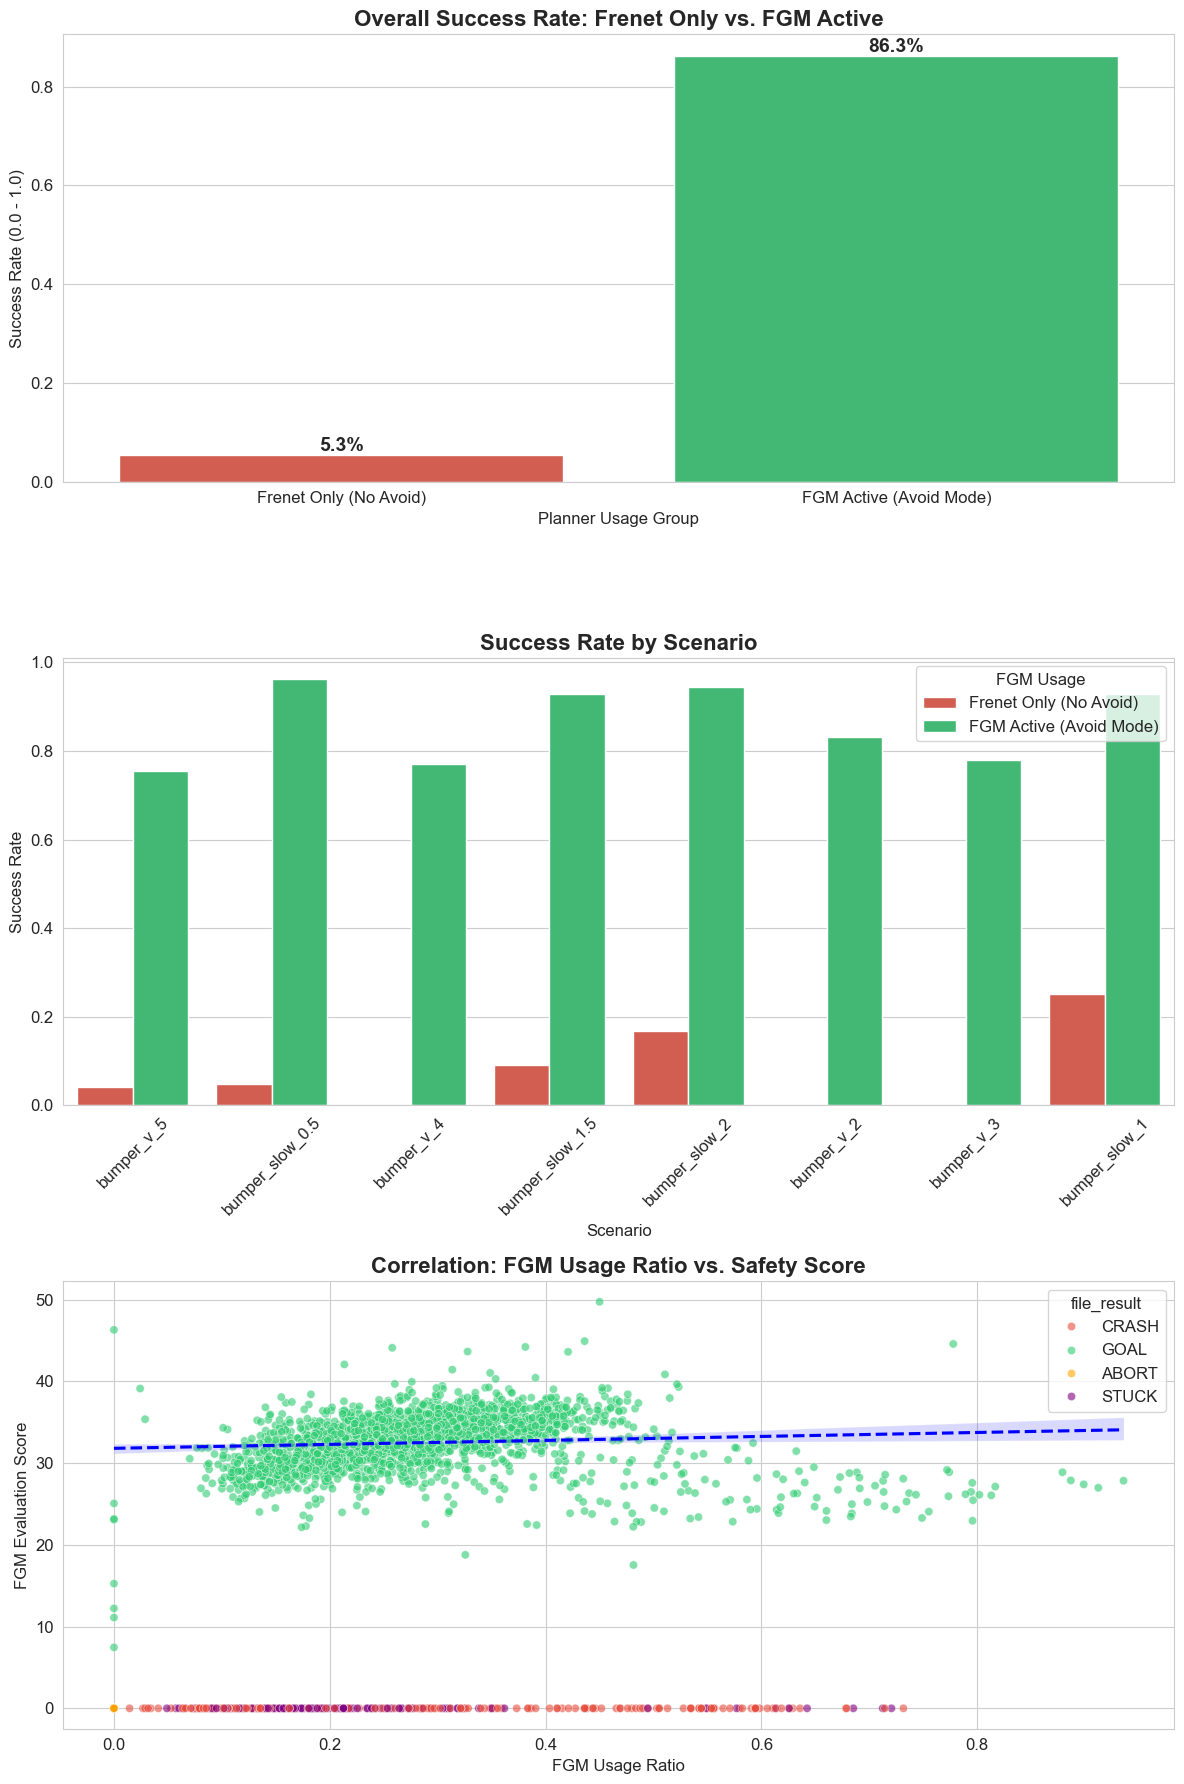

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 데이터 로드
file_path = './summary/simulation_results_mux_avoid.csv'
df = pd.read_csv(file_path)

# 2. 데이터 전처리
# (1) 성공 여부를 0과 1로 변환
df['is_success'] = (df['file_result'] == 'GOAL').astype(int)

# (2) 시나리오 이름 정리
df['scenario'] = df['opp_config'].str.replace('.csv', '', regex=False) \
                                 .str.replace('Opp_', '', regex=False)

# (3) FGM 개입 그룹 분류
bins = [-0.1, 0.001, 1.1]
labels = ['Frenet Only (No Avoid)', 'FGM Active (Avoid Mode)']
df['fgm_group'] = pd.cut(df['fgm_ratio'], bins=bins, labels=labels)

# ==============================================================================
# 📊 그래프 그리기
# ==============================================================================
plt.rcParams['figure.figsize'] = (12, 12)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

fig, axes = plt.subplots(3, 1, figsize=(12, 18))

# ------------------------------------------------------------------------------
# 1. 전체 성공률 비교
# ------------------------------------------------------------------------------
sns.barplot(x='fgm_group', y='is_success', data=df, ax=axes[0], palette=['#e74c3c', '#2ecc71'], errorbar=None)
axes[0].set_title("Overall Success Rate: Frenet Only vs. FGM Active", fontsize=16, fontweight='bold')
axes[0].set_ylabel("Success Rate (0.0 - 1.0)")
axes[0].set_xlabel("Planner Usage Group")
for p in axes[0].patches:
    axes[0].annotate(f'{p.get_height()*100:.1f}%',
                     (p.get_x() + p.get_width() / 2., p.get_height()),
                     ha='center', va='bottom', fontsize=14, fontweight='bold')

# ------------------------------------------------------------------------------
# 2. 시나리오별 성공률 비교
# ------------------------------------------------------------------------------
sns.barplot(x='scenario', y='is_success', hue='fgm_group', data=df, ax=axes[1], palette=['#e74c3c', '#2ecc71'], errorbar=None)
axes[1].set_title("Success Rate by Scenario", fontsize=16, fontweight='bold')
axes[1].set_ylabel("Success Rate")
axes[1].set_xlabel("Scenario")
axes[1].legend(title="FGM Usage")
axes[1].tick_params(axis='x', rotation=45)

# ------------------------------------------------------------------------------
# 3. FGM 비율 vs 안전 점수 산점도 [수정됨]
# ------------------------------------------------------------------------------
if 'Score_FGM' in df.columns:
    # [수정] 'STUCK' 상태에 대한 색상(보라색)을 추가했습니다.
    custom_palette = {
        'GOAL': '#2ecc71',   # 성공 (녹색)
        'CRASH': '#e74c3c',  # 충돌 (빨간색)
        'ABORT': 'orange',   # 중단 (주황색)
        'STUCK': 'purple'    # 고립 (보라색) - 추가됨
    }

    sns.scatterplot(x='fgm_ratio', y='Score_FGM', hue='file_result', data=df, ax=axes[2],
                    palette=custom_palette, alpha=0.6)

    # 추세선 (성공한 케이스만 파란 점선으로 표시)
    sns.regplot(x='fgm_ratio', y='Score_FGM', data=df[df['file_result']=='GOAL'], ax=axes[2],
                scatter=False, color='blue', line_kws={'linestyle':'--'})

    axes[2].set_title("Correlation: FGM Usage Ratio vs. Safety Score", fontsize=16, fontweight='bold')
    axes[2].set_xlabel("FGM Usage Ratio")
    axes[2].set_ylabel("FGM Evaluation Score")

plt.tight_layout()
plt.show()

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_28132\3338914402.py:39: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='fgm_bin', y='is_success', data=trend_data, ax=axes[0], palette='viridis', alpha=0.8)


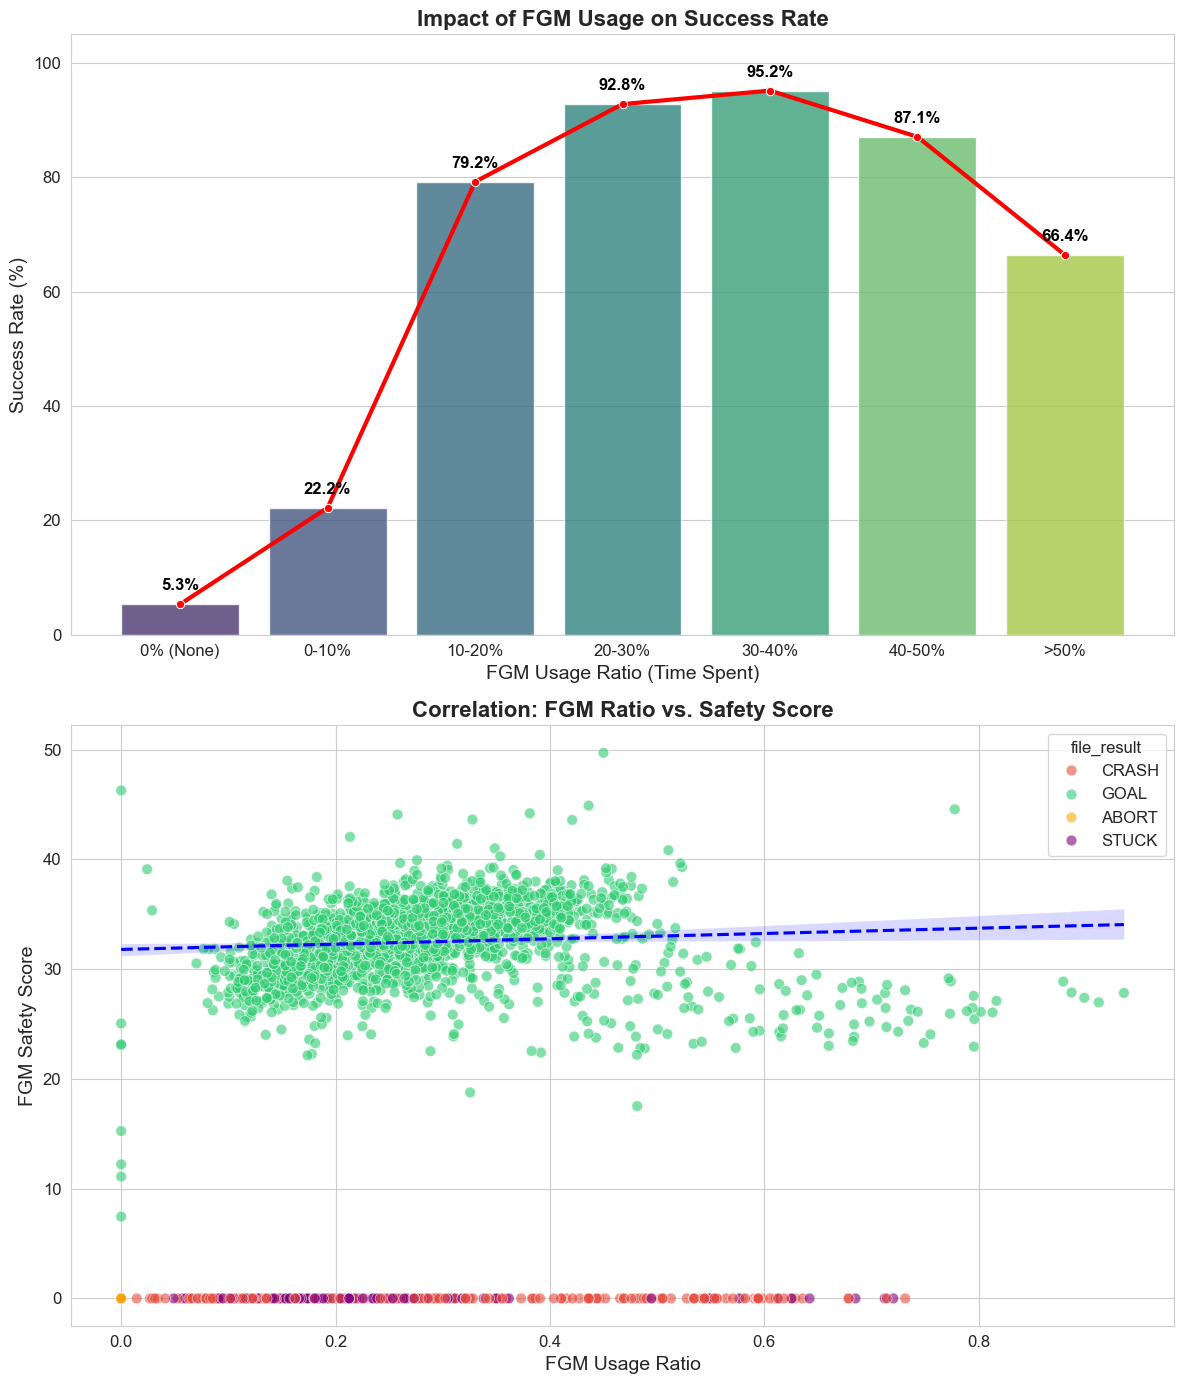

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 데이터 로드 (파일 경로 확인 필요)
file_path = './summary/simulation_results_mux_avoid.csv'
df = pd.read_csv(file_path)

# 2. 데이터 전처리
# 성공 여부를 0과 1로 변환 (GOAL = 1, 그 외 = 0)
df['is_success'] = (df['file_result'] == 'GOAL').astype(int)

# ------------------------------------------------------------------------------
# 3. FGM 사용 비율 구간화 (Binning)
# - 0% (미사용), 0-10%, 10-20% ... 50% 이상으로 세분화하여 추세를 봅니다.
# ------------------------------------------------------------------------------
bins = [-0.01, 0.001, 0.1, 0.2, 0.3, 0.4, 0.5, 1.01]
labels = ['0% (None)', '0-10%', '10-20%', '20-30%', '30-40%', '40-50%', '>50%']
df['fgm_bin'] = pd.cut(df['fgm_ratio'], bins=bins, labels=labels)

# 구간별 성공률 계산
trend_data = df.groupby('fgm_bin', observed=False)['is_success'].mean().reset_index()
trend_data['is_success'] *= 100  # 백분율로 변환

# ==============================================================================
# 📊 그래프 그리기
# ==============================================================================
plt.rcParams['figure.figsize'] = (12, 10)
plt.rcParams['font.size'] = 12
sns.set_style("whitegrid")

fig, axes = plt.subplots(2, 1, figsize=(12, 14))

# ------------------------------------------------------------------------------
# [그래프 1] FGM 사용 비율에 따른 성공률 변화 (막대 + 꺾은선)
# ------------------------------------------------------------------------------
# 막대 그래프 (Bar Plot)
sns.barplot(x='fgm_bin', y='is_success', data=trend_data, ax=axes[0], palette='viridis', alpha=0.8)
# 꺾은선 그래프 (Line Plot) - 추세를 강조하기 위해 추가
sns.lineplot(x='fgm_bin', y='is_success', data=trend_data, ax=axes[0], marker='o', color='red', linewidth=3, sort=False)

axes[0].set_title("Impact of FGM Usage on Success Rate", fontsize=16, fontweight='bold')
axes[0].set_ylabel("Success Rate (%)", fontsize=14)
axes[0].set_xlabel("FGM Usage Ratio (Time Spent)", fontsize=14)
axes[0].set_ylim(0, 105)

# 수치 표시 (Annotate)
for index, row in trend_data.iterrows():
    if not np.isnan(row['is_success']):
        axes[0].annotate(f"{row['is_success']:.1f}%", 
                         (index, row['is_success']), 
                         xytext=(0, 10), textcoords='offset points', ha='center', 
                         fontsize=12, fontweight='bold', color='black')

# ------------------------------------------------------------------------------
# [그래프 2] FGM 비율과 안전 점수의 상관관계 (산점도)
# ------------------------------------------------------------------------------
if 'Score_FGM' in df.columns:
    # 결과별 색상 지정 (STUCK 포함)
    unique_results = df['file_result'].unique()
    palette_colors = {'GOAL': '#2ecc71', 'CRASH': '#e74c3c', 'ABORT': 'orange', 'STUCK': 'purple'}
    plot_palette = {k: palette_colors.get(k, 'gray') for k in unique_results}

    sns.scatterplot(x='fgm_ratio', y='Score_FGM', hue='file_result', data=df, ax=axes[1], 
                    palette=plot_palette, alpha=0.6, s=60)
    
    # 성공한 케이스(GOAL)에 대해서만 추세선 그리기
    if 'GOAL' in unique_results:
        sns.regplot(x='fgm_ratio', y='Score_FGM', data=df[df['file_result']=='GOAL'], ax=axes[1], 
                    scatter=False, color='blue', line_kws={'linestyle':'--'})

    axes[1].set_title("Correlation: FGM Ratio vs. Safety Score", fontsize=16, fontweight='bold')
    axes[1].set_xlabel("FGM Usage Ratio", fontsize=14)
    axes[1].set_ylabel("FGM Safety Score", fontsize=14)

plt.tight_layout()
plt.show()

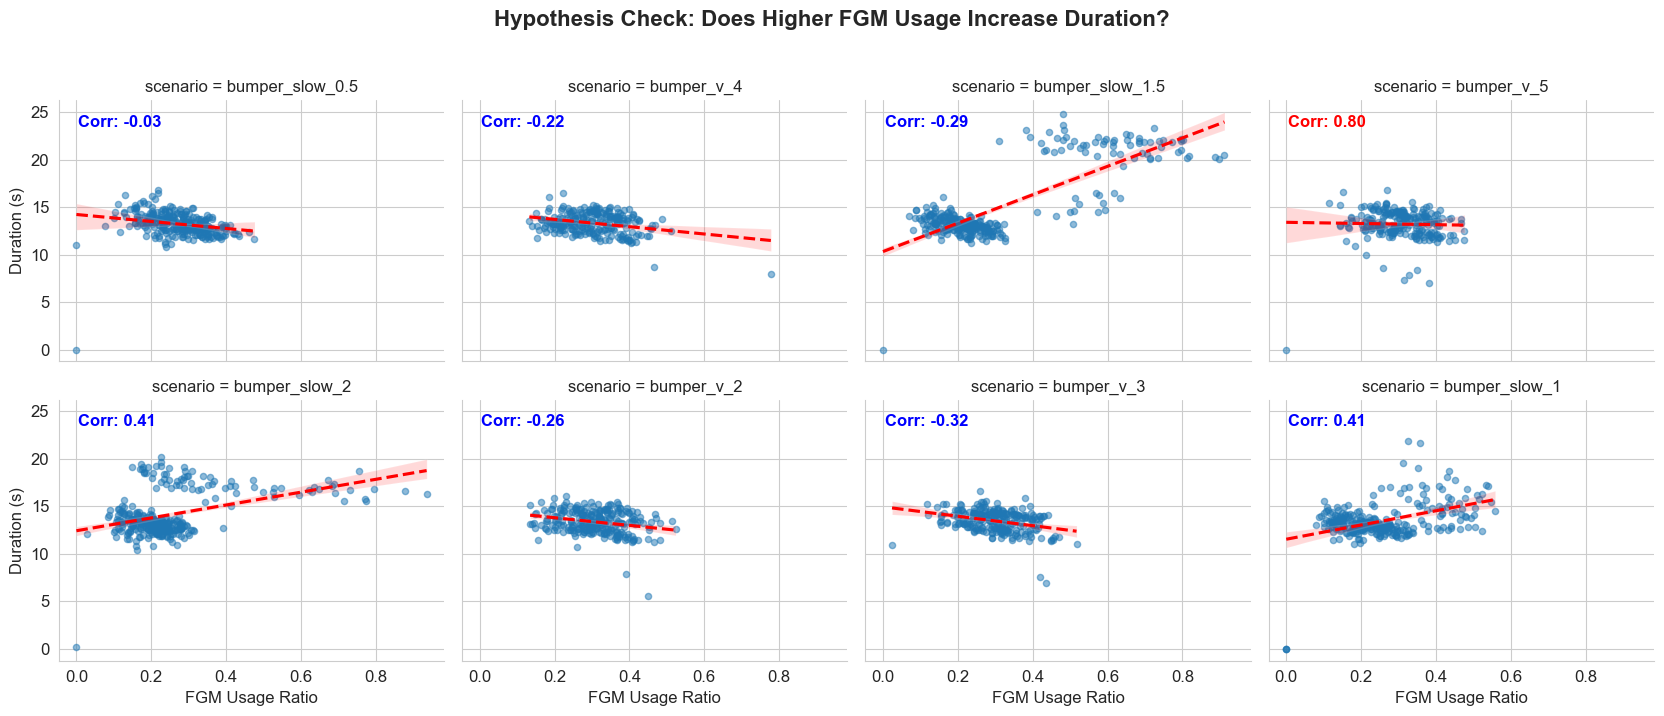


=== Scenario Breakdown Analysis ===
          scenario Success_Rate  Mean_FGM_Ratio  Mean_Duration  \
2  bumper_slow_1.5        90.0%        0.303516      14.749909   
7       bumper_v_5        70.1%        0.297355      11.039879   
6       bumper_v_4        71.9%        0.275307      11.737613   
4       bumper_v_2        79.5%        0.270097      12.294381   
5       bumper_v_3        73.7%        0.259896      12.238761   
3    bumper_slow_2        93.1%        0.246463      14.101057   
1    bumper_slow_1        90.3%        0.241432      13.433172   
0  bumper_slow_0.5        84.9%        0.235455      11.872085   

   Mean_Safety_Score  
2          26.792309  
7          24.401062  
6          24.905174  
4          27.461726  
5          25.445046  
3          27.983917  
1          27.866384  
0          27.483819  

                  [해석 가이드 (Interpretation)]
1. 상관계수(Corr)가 양수(+)이고 높을 경우 (예: > 0.5):
   -> FGM을 많이 쓸수록 주행 시간이 길어짐.
   -> '추월하지 않고 뒤따라갔다(Passive Following)'는 가설이

In [29]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 데이터 로드
file_path = './summary/simulation_results_mux_avoid.csv'
df = pd.read_csv(file_path)

# 2. 데이터 전처리
# 성공 여부 (0/1)
df['is_success'] = (df['file_result'] == 'GOAL').astype(int)
# 시나리오 이름 간소화
df['scenario'] = df['opp_config'].str.replace('.csv', '', regex=False).str.replace('Opp_', '', regex=False)

# 성공한 데이터만 추출 (주행 시간 분석용)
success_df = df[df['file_result'] == 'GOAL'].copy()

# ==============================================================================
# 📊 그래프 1: 시나리오별 [FGM 비율 vs 주행 시간] 상관관계 분석
# "FGM을 많이 쓰면 느려지는가?" (추월 포기/단순 추종 가설 검증)
# ==============================================================================
# 회귀선(Trend line)을 포함한 산점도 그리기
g = sns.lmplot(
    data=success_df, 
    x='fgm_ratio', 
    y='duration_s', 
    col='scenario',      # 시나리오별로 그래프 분할
    col_wrap=4,          # 한 줄에 4개씩 표시
    height=3.5, 
    aspect=1.2,
    line_kws={'color': 'red', 'linestyle': '--'}, # 추세선 스타일
    scatter_kws={'alpha': 0.5, 's': 20}
)

# 그래프 제목 및 스타일 설정
g.fig.suptitle("Hypothesis Check: Does Higher FGM Usage Increase Duration?", fontsize=16, fontweight='bold', y=1.02)
g.set_axis_labels("FGM Usage Ratio", "Duration (s)")

# 각 서브플롯에 상관계수(Corr) 표시
for ax, title in zip(g.axes.flat, df['scenario'].unique()):
    # 해당 시나리오 데이터 필터링
    subset = success_df[success_df['scenario'] == title.split(' = ')[-1]]
    if len(subset) > 1:
        corr = subset['fgm_ratio'].corr(subset['duration_s'])
        ax.text(0.05, 0.9, f'Corr: {corr:.2f}', transform=ax.transAxes, 
                fontsize=12, color='red' if corr > 0.5 else 'blue', fontweight='bold')

plt.tight_layout()
plt.show()

# ==============================================================================
# 📋 분석 테이블: 시나리오별 성공률 및 FGM 패턴 요약
# ==============================================================================
summary_table = df.groupby('scenario').agg(
    Success_Rate=('is_success', lambda x: f"{x.mean()*100:.1f}%"),
    Mean_FGM_Ratio=('fgm_ratio', 'mean'),
    Mean_Duration=('duration_s', 'mean'),
    Mean_Safety_Score=('Score_FGM', 'mean')
).reset_index()

# 보기 좋게 정렬 (성공률 낮은 순 -> 문제 구간 확인)
summary_table = summary_table.sort_values(by='Mean_FGM_Ratio', ascending=False)

print("\n=== Scenario Breakdown Analysis ===")
print(summary_table)

# ==============================================================================
# 💡 해석 가이드 출력
# ==============================================================================
print("\n" + "="*60)
print("                  [해석 가이드 (Interpretation)]")
print("="*60)
print("1. 상관계수(Corr)가 양수(+)이고 높을 경우 (예: > 0.5):")
print("   -> FGM을 많이 쓸수록 주행 시간이 길어짐.")
print("   -> '추월하지 않고 뒤따라갔다(Passive Following)'는 가설이 유력함.")
print("\n2. 상관계수가 0에 가깝거나 음수(-)일 경우:")
print("   -> FGM이 개입해도 주행 시간에 큰 손해가 없었음.")
print("   -> '효율적으로 회피하고 지나갔다(Active Overtaking)'는 증거.")
print("="*60)

C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_28132\2052971715.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  g = sns.catplot(


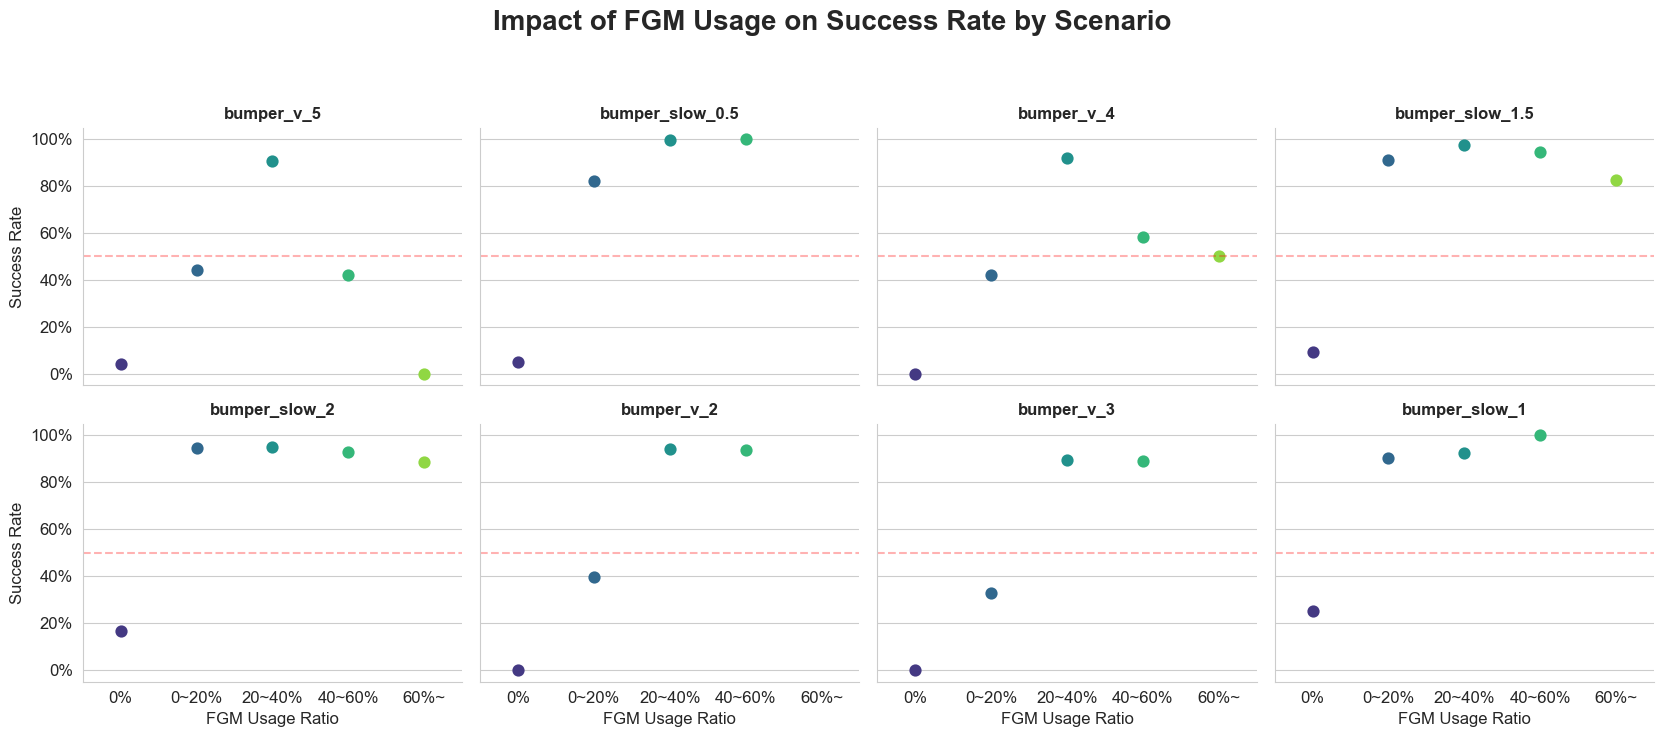

In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# 1. 데이터 로드
file_path = './summary/simulation_results_mux_avoid.csv'
df = pd.read_csv(file_path)

# 2. 데이터 전처리
df['is_success'] = (df['file_result'] == 'GOAL').astype(int)
df['scenario'] = df['opp_config'].str.replace('.csv', '', regex=False).str.replace('Opp_', '', regex=False)

# 3. FGM 비율 구간화 (0%, 0~20%, 20~40%...)
bins = [-0.01, 0.001, 0.2, 0.4, 0.6, 1.01]
labels = ['0%', '0~20%', '20~40%', '40~60%', '60%~']
df['fgm_bin'] = pd.cut(df['fgm_ratio'], bins=bins, labels=labels)

# ==============================================================================
# 📊 시각화: 시나리오별 FGM 비율에 따른 성공률 변화 (Point Plot)
# ==============================================================================
sns.set_style("whitegrid")

g = sns.catplot(
    data=df, 
    x='fgm_bin', 
    y='is_success', 
    col='scenario', 
    col_wrap=4,       # 한 줄에 4개씩 그래프 배치
    kind='point',     # 점+선 그래프로 추세 표현
    height=3.5, 
    aspect=1.2,
    palette='viridis',
    markers='o',
    linestyles='-',
    errorbar=None     # 신뢰구간 표시 끔 (깔끔하게 보기 위해)
)

# 그래프 제목 및 축 설정
g.fig.suptitle("Impact of FGM Usage on Success Rate by Scenario", fontsize=20, fontweight='bold', y=1.05)
g.set_axis_labels("FGM Usage Ratio", "Success Rate")
g.set_titles("{col_name}", fontsize=14, fontweight='bold')

# Y축을 %로 표시하고 0~100% 고정
for ax in g.axes.flat:
    ax.set_ylim(-0.05, 1.05)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{int(x*100)}%'))
    # 50% 기준선 추가
    ax.axhline(0.5, ls='--', c='red', alpha=0.3)

plt.tight_layout()
plt.show()

In [34]:
# 1. 데이터 로드
file_path = './summary/simulation_results_mux_params_avoid.csv'
df = pd.read_csv(file_path)

df.head()

,ws,wt,wc,wcl,wd,dm,Score_FGM_mean,Score_FGM_max,Score_FRENET_mean,Score_FRENET_max,duration_s_mean,collision_flag_sum,fgm_min_d_mean,fre_min_d_mean,fgm_ratio_mean,frenet_ratio_mean
0,0.93,2.02,1.36,2.20,2.46,0.48,34.849392,38.580269,31.470567,33.560821,13.64875,0,0.002829,0.008326,0.294904,0.705096
1,0.99,2.18,1.47,2.33,2.63,0.54,34.484444,38.546240,31.427791,35.647358,13.60875,0,0.004934,0.007547,0.255224,0.744776
2,1.50,2.47,1.69,2.56,2.82,0.58,34.443281,39.939051,31.089140,32.979911,13.73375,0,0.003750,0.007781,0.262642,0.737358
3,1.75,1.60,0.98,1.32,0.53,0.47,34.402924,37.801933,35.589440,37.419562,11.72500,0,0.003632,0.017816,0.367387,0.632613
4,1.12,2.38,1.66,2.44,2.80,0.54,34.376722,37.927877,31.263158,35.161952,13.52500,0,0.004287,0.007953,0.289831,0.710169


삭제할 아웃라이어 데이터:
      duration_s  total_dist_m      ws      wd
303       52.63        226.31  0.8841  1.0629

제거 전 데이터 수: 322, 제거 후 데이터 수: 321


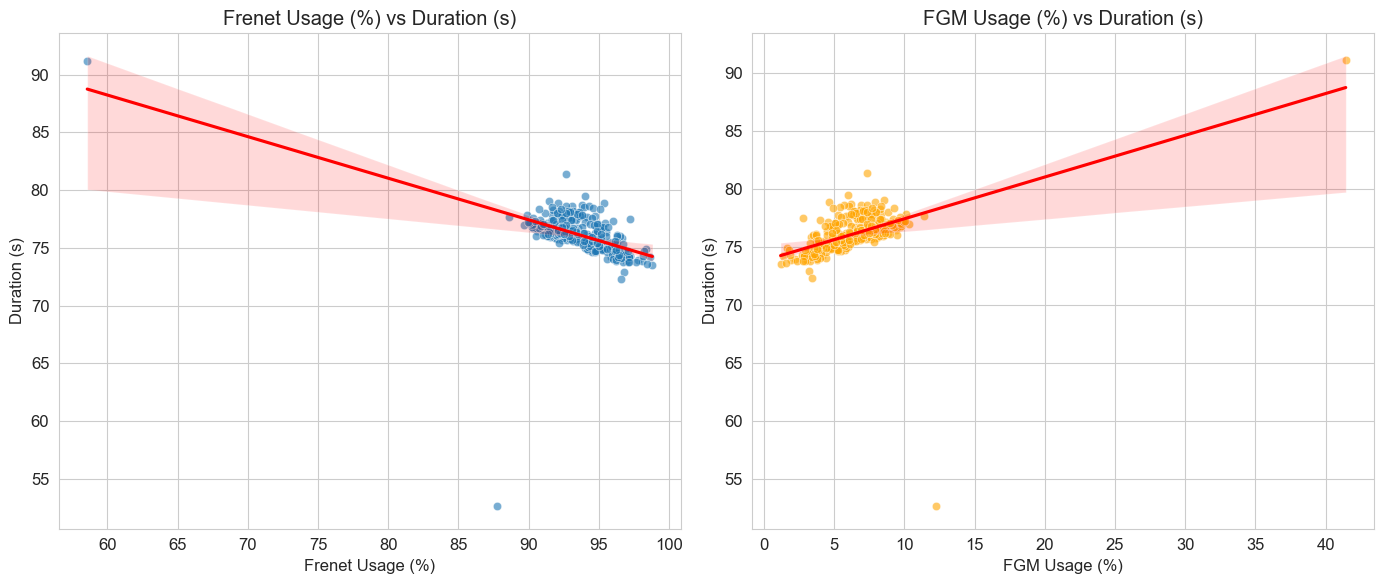

In [72]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드
file_path = './summary/simulation_summary_mux_speed.csv'
df = pd.read_csv(file_path)

# 2. Spielberg 맵 + 성공 데이터 필터링
df_spielberg = df[(df['map'] == 'Spielberg') & (df['is_success'] == True)].copy()

# 3. 52초대 아웃라이어 확인 및 제거
# 52초 근처의 데이터를 확인합니다.
outlier_mask = df_spielberg['duration_s'] < 60
print("삭제할 아웃라이어 데이터:\n", df_spielberg[outlier_mask][['duration_s', 'total_dist_m', 'ws', 'wd']])

# 아웃라이어 제거
df_clean = df_spielberg[~outlier_mask].copy()
print(f"\n제거 전 데이터 수: {len(df_spielberg)}, 제거 후 데이터 수: {len(df_clean)}")


# 2. 데이터 필터링
# 주행 시간 분석은 완주한 데이터(Goal Reached)를 기준으로 하는 것이 정확합니다.
df_success = df[(df['map'] == 'Spielberg') & (df['is_success'] == True)].copy()


# 3. 그래프 그리기
plt.figure(figsize=(14, 6))

# Frenet 사용 비율 vs 시간
plt.subplot(1, 2, 1)
sns.scatterplot(data=df_success, x='frenet_usage_pct', y='duration_s', alpha=0.6)
# 추세선 추가 (경향성 파악 용도)
sns.regplot(data=df_success, x='frenet_usage_pct', y='duration_s', scatter=False, color='red')
plt.title('Frenet Usage (%) vs Duration (s)')
plt.xlabel('Frenet Usage (%)')
plt.ylabel('Duration (s)')
plt.grid(True)

# FGM 사용 비율 vs 시간
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_success, x='fgm_usage_pct', y='duration_s', alpha=0.6, color='orange')
# 추세선 추가
sns.regplot(data=df_success, x='fgm_usage_pct', y='duration_s', scatter=False, color='red')
plt.title('FGM Usage (%) vs Duration (s)')
plt.xlabel('FGM Usage (%)')
plt.ylabel('Duration (s)')
plt.grid(True)

plt.tight_layout()
plt.show()

Correlation of Weights with Total Distance:
 ws     0.287706
wt    -0.340281
wc    -0.306245
wcl   -0.429663
wd    -0.486571
dm    -0.185173
Name: total_dist_m, dtype: float64

Correlation of Weights with Max Lat Acc:
 ws     0.075118
wt    -0.058457
wc    -0.082894
wcl   -0.131533
wd    -0.183788
dm    -0.078661
Name: max_lat_acc, dtype: float64


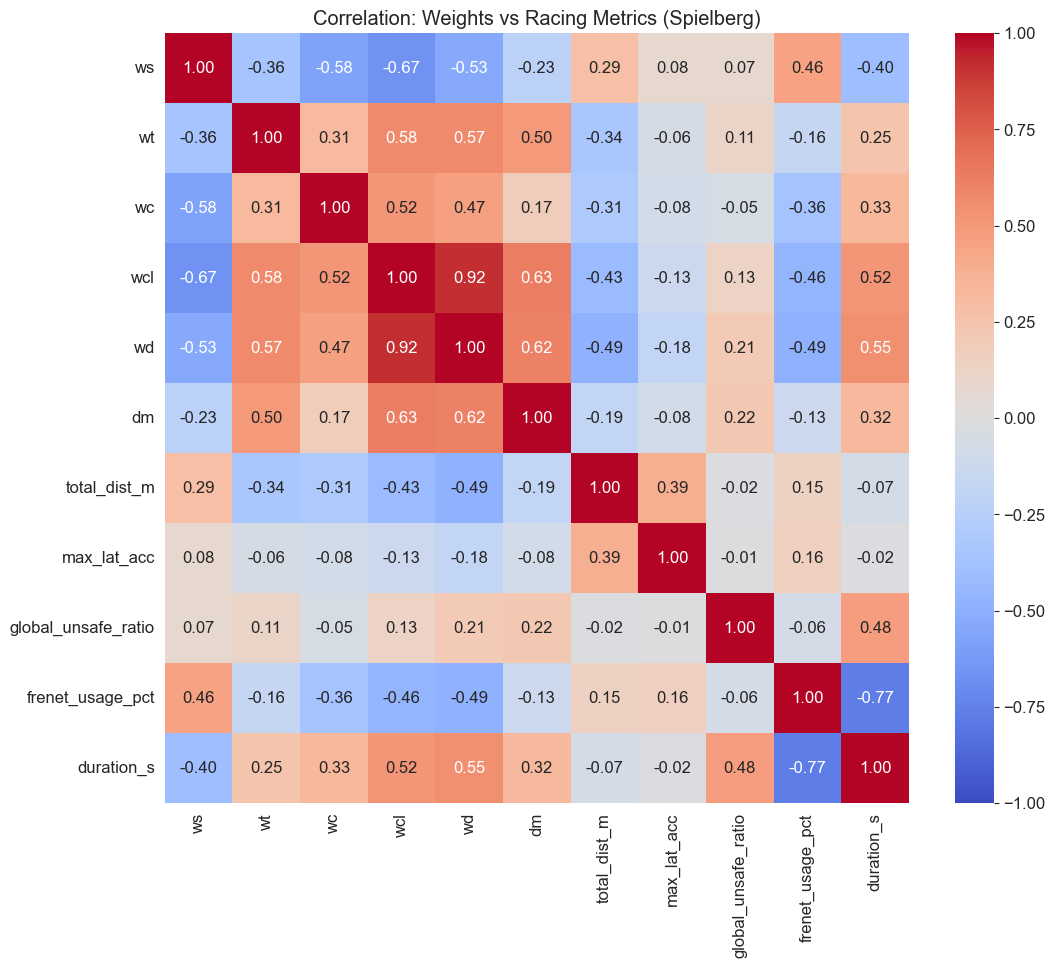

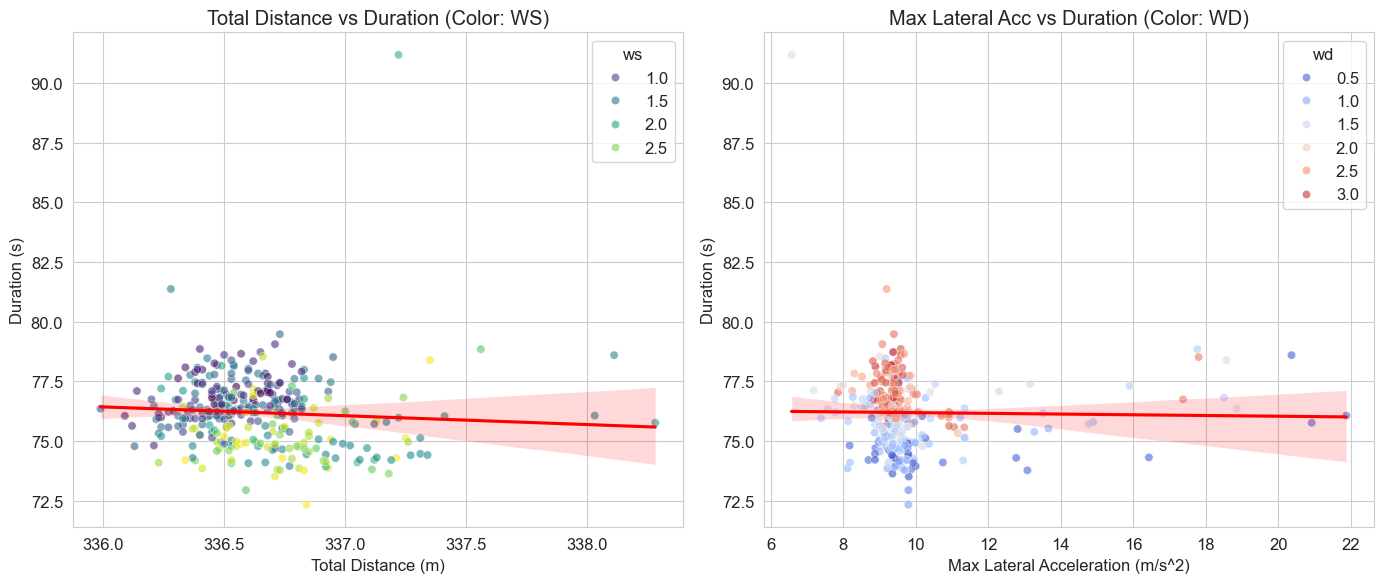

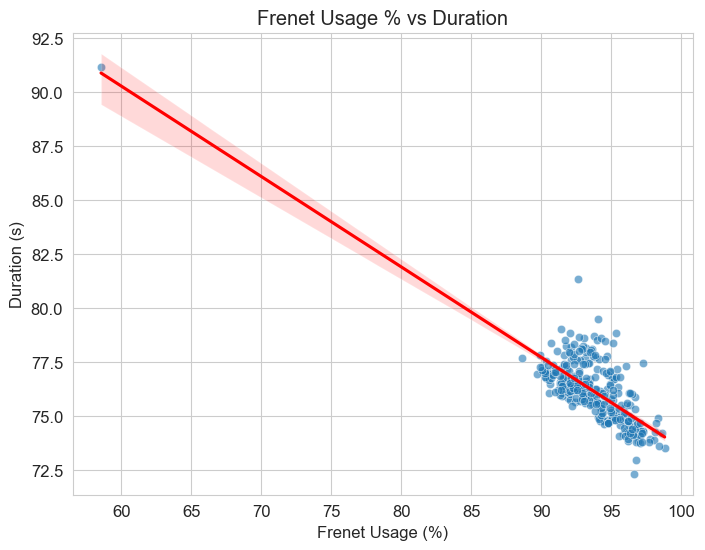

In [74]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. 데이터 로드 및 전처리
file_path = './summary/simulation_summary_mux_speed.csv'
df = pd.read_csv(file_path)

# Spielberg 맵 & 완주 데이터 & 이상치 제거 (60초 이상)
df_spielberg = df[(df['map'] == 'Spielberg') & (df['is_success'] == True) & (df['duration_s'] > 60)].copy()

# 분석할 추가 지표들
metrics = ['total_dist_m', 'max_lat_acc', 'global_unsafe_ratio', 'frenet_usage_pct', 'duration_s']
weights = ['ws', 'wt', 'wc', 'wcl', 'wd', 'dm']

# 2. 상관관계 분석 (가중치 vs 주행 스타일 지표)
# 가중치가 주행 스타일(거리, 횡가속도 등)에 미치는 영향 파악
correlation_matrix = df_spielberg[weights + metrics].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation: Weights vs Racing Metrics (Spielberg)')
plt.savefig('advanced_correlation_spielberg.png')

# 3. 주행 효율성 분석 (Time vs Distance)
plt.figure(figsize=(14, 6))

plt.subplot(1, 2, 1)
sns.scatterplot(data=df_spielberg, x='total_dist_m', y='duration_s', alpha=0.6, hue='ws', palette='viridis')
sns.regplot(data=df_spielberg, x='total_dist_m', y='duration_s', scatter=False, color='red')
plt.title('Total Distance vs Duration (Color: WS)')
plt.xlabel('Total Distance (m)')
plt.ylabel('Duration (s)')

# 4. 주행 안정성/공격성 분석 (Time vs Lateral Acc)
plt.subplot(1, 2, 2)
sns.scatterplot(data=df_spielberg, x='max_lat_acc', y='duration_s', alpha=0.6, hue='wd', palette='coolwarm')
sns.regplot(data=df_spielberg, x='max_lat_acc', y='duration_s', scatter=False, color='red')
plt.title('Max Lateral Acc vs Duration (Color: WD)')
plt.xlabel('Max Lateral Acceleration (m/s^2)')
plt.ylabel('Duration (s)')

plt.tight_layout()
plt.savefig('racing_efficiency_analysis.png')

# 5. 알고리즘 의존도 분석 (Frenet Usage vs Duration)
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df_spielberg, x='frenet_usage_pct', y='duration_s', alpha=0.6)
sns.regplot(data=df_spielberg, x='frenet_usage_pct', y='duration_s', scatter=False, color='red')
plt.title('Frenet Usage % vs Duration')
plt.xlabel('Frenet Usage (%)')
plt.ylabel('Duration (s)')
plt.grid(True)
plt.savefig('frenet_usage_vs_duration.png')

print("Correlation of Weights with Total Distance:\n", correlation_matrix['total_dist_m'][weights])
print("\nCorrelation of Weights with Max Lat Acc:\n", correlation_matrix['max_lat_acc'][weights])

Decision Tree Rules:
 |--- wd <= 1.69
|   |--- ws <= 0.89
|   |   |--- ws <= 0.86
|   |   |   |--- value: [75.86]
|   |   |--- ws >  0.86
|   |   |   |--- value: [52.63]
|   |--- ws >  0.89
|   |   |--- wd <= 1.10
|   |   |   |--- value: [74.73]
|   |   |--- wd >  1.10
|   |   |   |--- value: [75.71]
|--- wd >  1.69
|   |--- wcl <= 1.48
|   |   |--- wd <= 1.83
|   |   |   |--- value: [76.59]
|   |   |--- wd >  1.83
|   |   |   |--- value: [91.17]
|   |--- wcl >  1.48
|   |   |--- wcl <= 2.00
|   |   |   |--- value: [76.30]
|   |   |--- wcl >  2.00
|   |   |   |--- value: [77.05]



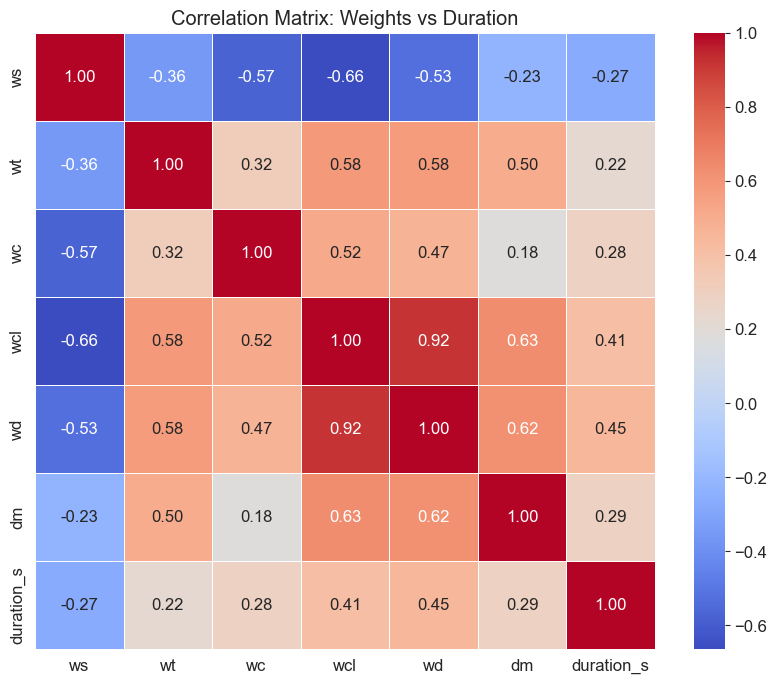

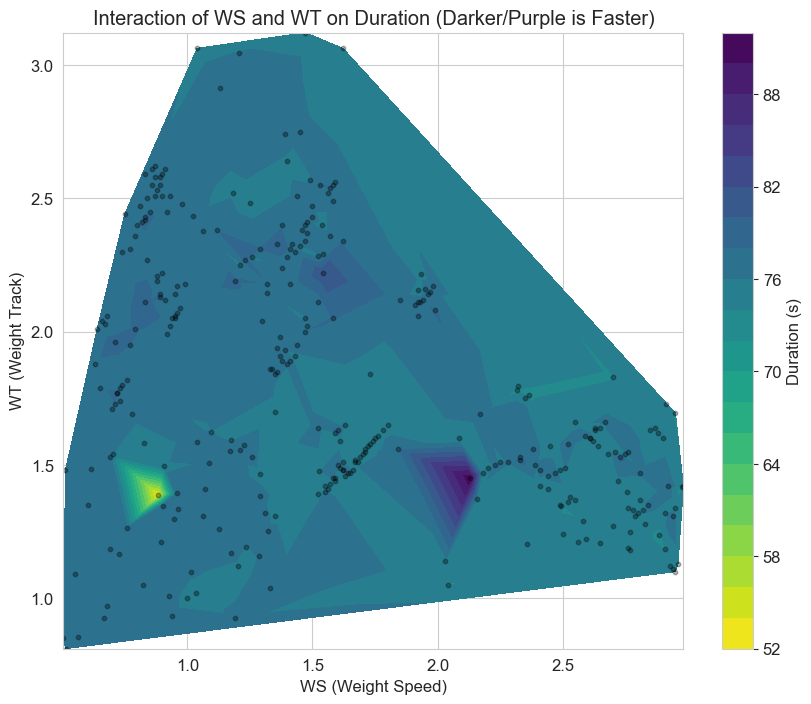

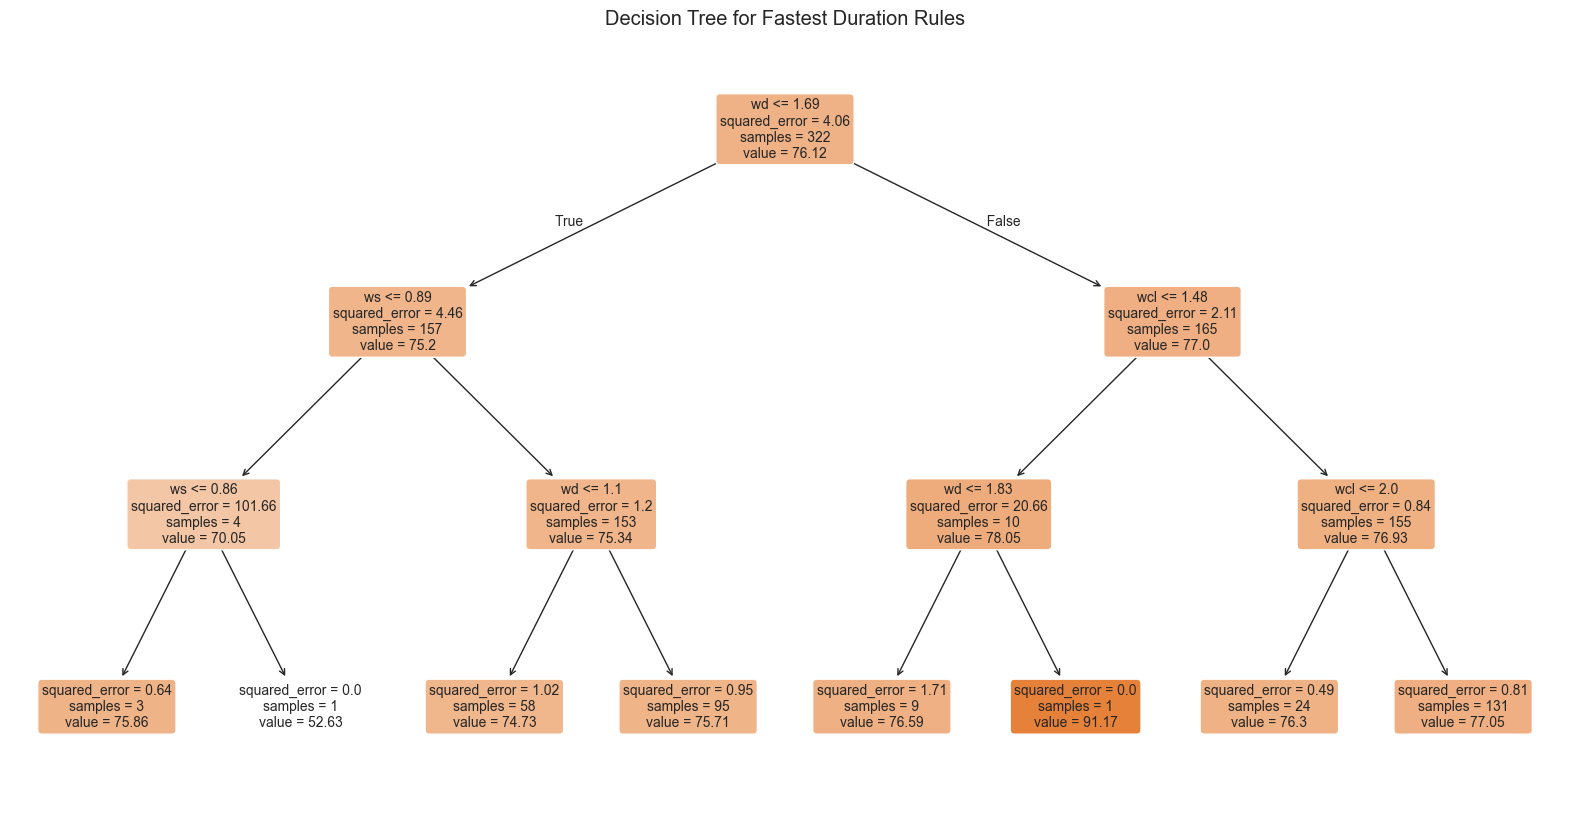

In [43]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeRegressor, plot_tree, export_text

# 데이터 로드 및 전처리
df = pd.read_csv('./summary/simulation_summary_mux_speed.csv')
df_success = df[(df['map'] == 'Spielberg') & (df['is_success'] == True)].copy()
weights = ['ws', 'wt', 'wc', 'wcl', 'wd', 'dm']

# 1. 상관관계 분석 (Heatmap)
plt.figure(figsize=(10, 8))
corr = df_success[weights + ['duration_s']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Matrix: Weights vs Duration')
plt.savefig('correlation_heatmap.png')

# 2. 조합 분석: "Sweet Spot" 찾기 (Contour Plot)
# 가장 중요한 변수 2개 (ws, wt)에 따른 시간의 변화를 등고선으로 표현
plt.figure(figsize=(10, 8))
# 등고선을 그리기 위해 tricontourf 사용 (데이터가 격자 형태가 아닐 때 유용)
plt.tricontourf(df_success['ws'], df_success['wt'], df_success['duration_s'], levels=20, cmap='viridis_r')
plt.colorbar(label='Duration (s)')
plt.scatter(df_success['ws'], df_success['wt'], c='black', s=10, alpha=0.3) # 실제 데이터 포인트 표시
plt.xlabel('WS (Weight Speed)')
plt.ylabel('WT (Weight Track)')
plt.title('Interaction of WS and WT on Duration (Darker/Purple is Faster)')
plt.savefig('interaction_contour.png')

# 3. Decision Tree를 통한 규칙 추출
# 깊이가 3인 트리를 학습시켜서 어떤 조건일 때 시간이 짧은지 찾습니다.
dt = DecisionTreeRegressor(max_depth=3, random_state=42)
dt.fit(df_success[weights], df_success['duration_s'])

# 트리 시각화
plt.figure(figsize=(20, 10))
plot_tree(dt, feature_names=weights, filled=True, rounded=True, precision=2, fontsize=10)
plt.title('Decision Tree for Fastest Duration Rules')
plt.savefig('decision_tree_rules.png')

# 텍스트로 규칙 추출
tree_rules = export_text(dt, feature_names=weights)
print("Decision Tree Rules:\n", tree_rules)

In [45]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error

# 1. 데이터 로드 및 전처리
df = pd.read_csv('./summary/simulation_summary_mux_speed.csv')
df_spielberg = df[(df['map'] == 'Spielberg') & (df['is_success'] == True)].copy()

weights = ['ws', 'wt', 'wc', 'wcl', 'wd', 'dm']
X = df_spielberg[weights]
y = df_spielberg['duration_s']

# 2. 예측 모델 학습 (Random Forest)
# 데이터가 적을 수 있으므로 전체 데이터를 학습에 사용하여 패턴을 최대한 익히게 함
rf_model = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_model.fit(X, y)

# 3. 최적 가중치 탐색 (Random Search using the trained model)
# 각 가중치의 최소/최대 범위 확인
bounds = {}
for w in weights:
    bounds[w] = (df_spielberg[w].min(), df_spielberg[w].max())

print("Parameter Bounds:", bounds)

# 가상의 가중치 조합 100,000개 생성
n_samples = 100000
random_search_data = {}
np.random.seed(42)
for w in weights:
    low, high = bounds[w]
    random_search_data[w] = np.random.uniform(low, high, n_samples)

X_virtual = pd.DataFrame(random_search_data)

# 학습된 모델로 가상 데이터의 주행 시간 예측
predicted_durations = rf_model.predict(X_virtual)
X_virtual['predicted_duration'] = predicted_durations

# 예측 시간이 가장 짧은 상위 5개 조합 추출
best_virtual_configs = X_virtual.sort_values('predicted_duration').head(5)

# 실제 데이터에서의 Best (비교용)
best_actual_config = df_spielberg.sort_values('duration_s').head(1)[weights + ['duration_s']]

print("\nBest Actual Config (In Data):\n", best_actual_config)
print("\nBest Predicted Configs (AI Proposal):\n", best_virtual_configs)

Parameter Bounds: {'ws': (0.5053, 2.9819), 'wt': (0.8112, 3.1207), 'wc': (0.4106, 3.167), 'wcl': (0.3048, 3.0026), 'wd': (0.3505, 3.14), 'dm': (0.1251, 1.0)}

Best Actual Config (In Data):
          ws      wt      wc     wcl      wd      dm  duration_s
303  0.8841  1.3866  0.8504  1.3767  1.0629  0.2115       52.63

Best Predicted Configs (AI Proposal):
              ws        wt        wc       wcl        wd        dm  \
94801  0.872660  1.232661  0.641428  1.417109  0.817775  0.334217   
27746  0.865054  0.897269  0.955111  0.615810  0.782765  0.678166   
18358  0.891023  1.064052  0.419228  1.452744  0.501262  0.677089   
93002  0.891762  0.956928  0.806687  1.441913  0.739987  0.641849   
38430  0.861005  1.414561  1.352730  0.315869  0.472534  0.738293   

       predicted_duration  
94801            64.77670  
27746            64.85120  
18358            64.91695  
93002            64.97420  
38430            65.00745  


In [ ]:
df_spielberg = df[(df['map'] == 'Spielberg') & (df['is_success'] == True)]

df_spielberg.sort_values(by=['duration_s'], axis=0)[['ws', 'wt', 'wc', 'wcl', 'wd', 'wd', 'duration_s', 'map']]
# 1등값이 잘못나왔음

,ws,wt,wc,wcl,wd,wd,duration_s,map
303,0.8841,1.3866,0.8504,1.3767,1.0629,1.0629,52.63,Spielberg
300,2.9772,1.4183,0.9777,0.5069,0.9121,0.9121,72.34,Spielberg
212,2.3160,1.7818,0.5751,0.7190,0.6781,0.6781,72.95,Spielberg
165,2.8861,1.2360,0.8526,0.5532,0.3505,0.3505,73.52,Spielberg
396,2.4932,1.3465,0.5484,0.6115,0.3530,0.3530,73.64,Spielberg
...,...,...,...,...,...,...,...,...
206,0.7100,1.9600,1.4900,2.6300,2.8700,2.8700,78.86,Spielberg
5,0.8300,2.1100,1.4300,2.2900,2.6000,2.6000,79.06,Spielberg
12,1.3600,2.3300,1.5700,2.4400,2.7100,2.7100,79.48,Spielberg
135,1.5400,2.2200,1.3300,2.1700,2.4400,2.4400,81.37,Spielberg


C:\Users\Public\Documents\ESTsoft\CreatorTemp\ipykernel_28132\555860599.py:40: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_race_filterd = df_race_filtered[df_race['duration_s'] >60]
C:\Users\sunj0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\sunj0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(
C:\Users\sunj0\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\sklearn\utils\validation.py:2749: UserWarning: X d

Best Empirical Params (From Data):
ws                     1.750000
wt                     1.600000
wc                     0.980000
wcl                    1.320000
wd                     0.530000
dm                     0.470000
Avoid_Score           34.402924
Avoid_Success_Rate     1.000000
Race_Duration         74.710000
Avoid_Score_Norm       0.985652
Race_Score_Norm        0.427089
Total_Score            0.706371
Name: 216, dtype: float64

Best Solved Params (AI Prediction):
[1.75 1.6  0.98 1.32 0.53 0.47]


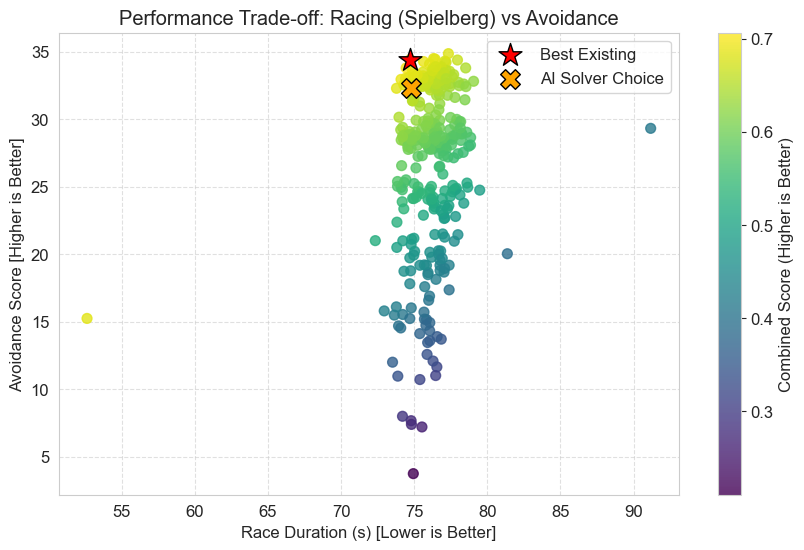

In [86]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.ensemble import RandomForestRegressor
from scipy.optimize import minimize
import matplotlib.pyplot as plt

# 1. 데이터 로드
df_avoid = pd.read_csv('./summary/simulation_results_mux_avoid.csv')
df_race = pd.read_csv('./summary/simulation_summary_mux_speed.csv')

# 2. 데이터 전처리

# [Avoidance Scenario]
# 파라미터별로 그룹화하여 평균 점수 및 충돌률 계산
# params: ws, wt, wc, wcl, wd, dm
param_cols = ['ws', 'wt', 'wc', 'wcl', 'wd', 'dm']

# Avoidance Metric: Score_FGM (높을수록 좋음) 혹은 충돌 여부.
# 여기서는 Score_FGM_mean을 사용하거나, raw data에서 다시 계산.
# raw data이므로 그룹화 필요.
# 충돌 안 난 것의 비율(Success Rate)과 Score 평균을 고려.
# user said "avoid에서는 회피를 잘한것".
# Score_FGM seems to capture safety/progress. Let's use Score_FGM.
# Also consider collision_flag (False is good).
df_avoid_grouped = df_avoid.groupby(param_cols).agg({
    'Score_FGM': 'mean',
    'collision_flag': lambda x: 1 - x.mean() # Success Rate (1 - collision rate)
}).reset_index()
df_avoid_grouped.rename(columns={'Score_FGM': 'Avoid_Score', 'collision_flag': 'Avoid_Success_Rate'}, inplace=True)


# [Racing Scenario]
# Filter: Map == Spielberg (contain check), Exclude Hairpin (explicit check just in case)
df_race_filtered = df_race[
    (df_race['map'].str.contains('Spielberg', case=False, na=False)) &
    (~df_race['map'].str.contains('hairpin', case=False, na=False)) 
]

df_race_filterd = df_race_filtered[df_race['duration_s'] >60]

# Metric: Duration (낮을수록 좋음).
# 완주한 경우만 고려 (is_success == True)
df_race_success = df_race_filtered[df_race_filtered['is_success'] == True]

# 파라미터별 평균 기록 계산
df_race_grouped = df_race_success.groupby(param_cols)['duration_s'].mean().reset_index()
df_race_grouped.rename(columns={'duration_s': 'Race_Duration'}, inplace=True)

# 3. 데이터 병합 (Inner Join)
# 두 시나리오 모두에서 실험된 파라미터 조합만 남김
df_merged = pd.merge(df_avoid_grouped, df_race_grouped, on=param_cols, how='inner')

# 4. 정규화 및 종합 점수 계산
# Avoid_Score: Maximize
# Race_Duration: Minimize

scaler = MinMaxScaler()

# Avoid 점수 정규화 (0~1, 클수록 좋음)
df_merged['Avoid_Score_Norm'] = scaler.fit_transform(df_merged[['Avoid_Score']])

# Race 시간 정규화 (0~1, 작을수록 좋음 -> 뒤집어서 클수록 좋게 만듦)
# Duration이 짧을수록 점수가 높아야 함.
# 1 - normalized_duration (where min duration maps to 0 originally? No.)
# Better: (Max - x) / (Max - Min)
d_min = df_merged['Race_Duration'].min()
d_max = df_merged['Race_Duration'].max()
df_merged['Race_Score_Norm'] = (d_max - df_merged['Race_Duration']) / (d_max - d_min)

# 종합 점수 (50:50 가중치)
df_merged['Total_Score'] = 0.5 * df_merged['Avoid_Score_Norm'] + 0.5 * df_merged['Race_Score_Norm']

# 5. 최적 파라미터 선정 (Empirical Best)
best_row_idx = df_merged['Total_Score'].idxmax()
best_empirical = df_merged.loc[best_row_idx]

# 6. Solver (AI Optimization) 구현
# 두 개의 모델을 만듦: Avoid_Predictor, Race_Predictor

X = df_merged[param_cols]
y_avoid = df_merged['Avoid_Score']
y_race = df_merged['Race_Duration']

model_avoid = RandomForestRegressor(n_estimators=100, random_state=42)
model_avoid.fit(X, y_avoid)

model_race = RandomForestRegressor(n_estimators=100, random_state=42)
model_race.fit(X, y_race)

# 목적 함수 정의
# Total Score를 최대화해야 함.
# Avoid는 최대화, Race는 최소화.
# 정규화 계수(min, max)는 기존 데이터 분포를 따름.
avoid_min, avoid_max = y_avoid.min(), y_avoid.max()
race_min, race_max = y_race.min(), y_race.max()

def objective_function(params):
    # params: [ws, wt, wc, wcl, wd, dm]
    p = params.reshape(1, -1)

    pred_avoid = model_avoid.predict(p)[0]
    pred_race = model_race.predict(p)[0]

    # Normalize
    # Clip predictions to plausible range to avoid extreme extrapolation issues
    pred_avoid = np.clip(pred_avoid, avoid_min, avoid_max)
    pred_race = np.clip(pred_race, race_min, race_max)

    norm_avoid = (pred_avoid - avoid_min) / (avoid_max - avoid_min) if avoid_max > avoid_min else 0
    norm_race = (race_max - pred_race) / (race_max - race_min) if race_max > race_min else 0

    total_score = 0.5 * norm_avoid + 0.5 * norm_race
    return -total_score # Minimize negative score

# 최적화 수행
bounds = [(df_merged[c].min(), df_merged[c].max()) for c in param_cols]
initial_guess = best_empirical[param_cols].values

res = minimize(objective_function, initial_guess, bounds=bounds, method='L-BFGS-B')
best_solved_params = res.x
best_solved_score = -res.fun

# 결과 출력
print("Best Empirical Params (From Data):")
print(best_empirical)
print("\nBest Solved Params (AI Prediction):")
print(best_solved_params)

# Visualization Data Preparation
# Scatter plot: Avoidance Score vs Race Time
# Color by Total Score
plt.figure(figsize=(10, 6))
sc = plt.scatter(df_merged['Race_Duration'], df_merged['Avoid_Score'],
            c=df_merged['Total_Score'], cmap='viridis', s=50, alpha=0.8)
plt.colorbar(sc, label='Combined Score (Higher is Better)')

# Highlight Best Empirical
plt.scatter(best_empirical['Race_Duration'], best_empirical['Avoid_Score'],
            color='red', marker='*', s=300, label='Best Existing', edgecolors='black')

# Predict scores for Solved Params to plot them
solved_pred_avoid = model_avoid.predict(best_solved_params.reshape(1, -1))[0]
solved_pred_race = model_race.predict(best_solved_params.reshape(1, -1))[0]

plt.scatter(solved_pred_race, solved_pred_avoid,
            color='orange', marker='X', s=200, label='AI Solver Choice', edgecolors='black')

plt.xlabel('Race Duration (s) [Lower is Better]')
plt.ylabel('Avoidance Score [Higher is Better]')
plt.title('Performance Trade-off: Racing (Spielberg) vs Avoidance')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.savefig('optimization_plot.png')

# Output result variables
best_empirical_dict = best_empirical.to_dict()
best_solved_list = best_solved_params.tolist()

=== Correlation Analysis (Which weight kills speed?) ===
     Avoid_Score  Race_Duration
ws     -0.090572      -0.268040
wt      0.153264       0.222871
wc      0.046674       0.281996
wcl     0.417342       0.414669
wd      0.357184       0.449442
dm      0.645779       0.291518

=== Alternative Optima 1: Fastest possible while keeping High Safety (Top 20%) ===
ws                2.580000
wt                1.290000
wc                0.730000
wcl               1.220000
wd                1.410000
dm                0.370000
Avoid_Score      32.939724
Race_Duration    74.100000
Name: 271, dtype: float64

=== Alternative Optima 2: Safest possible while keeping High Speed (Top 20%) ===
ws                1.750000
wt                1.600000
wc                0.980000
wcl               1.320000
wd                0.530000
dm                0.470000
Avoid_Score      34.402924
Race_Duration    74.710000
Name: 216, dtype: float64


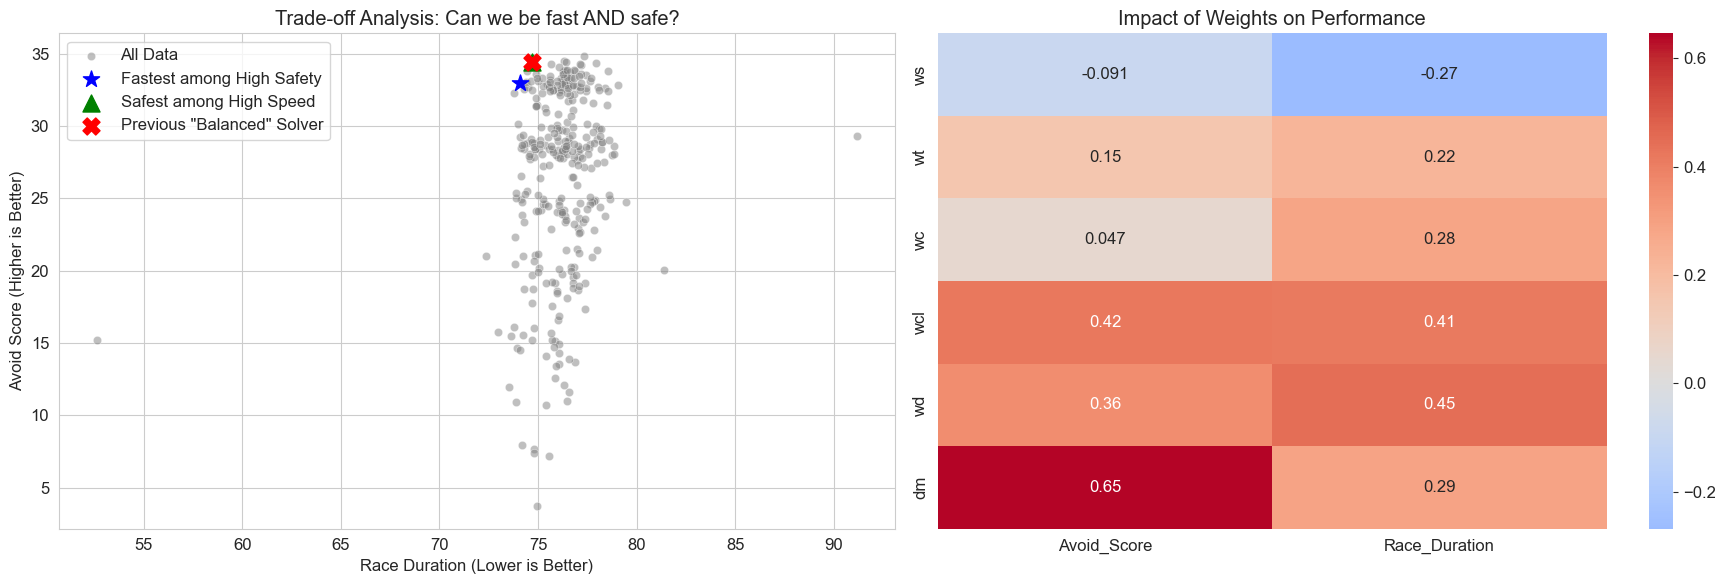

In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드 및 전처리 (이전과 동일)
df_avoid = pd.read_csv('./summary/simulation_results_mux_avoid.csv')
df_race = pd.read_csv('./summary/simulation_summary_mux_speed.csv')

param_cols = ['ws', 'wt', 'wc', 'wcl', 'wd', 'dm']

# Avoidance Grouping
df_avoid_grouped = df_avoid.groupby(param_cols)['Score_FGM'].mean().reset_index()
df_avoid_grouped.rename(columns={'Score_FGM': 'Avoid_Score'}, inplace=True)

# Racing Grouping (Spielberg, Success only)
df_race_filtered = df_race[
    (df_race['map'].str.contains('Spielberg', case=False, na=False)) &
    (~df_race['map'].str.contains('hairpin', case=False, na=False)) &
    (df_race['is_success'] == True)
]
df_race_grouped = df_race_filtered.groupby(param_cols)['duration_s'].mean().reset_index()
df_race_grouped.rename(columns={'duration_s': 'Race_Duration'}, inplace=True)

# Merge
df_merged = pd.merge(df_avoid_grouped, df_race_grouped, on=param_cols, how='inner')

# 2. 상관관계 분석 (파라미터가 성능에 미치는 영향)
# 어떤 파라미터가 속도를 갉아먹고 있는지(Race Duration을 높이는지) 확인
correlation_cols = param_cols + ['Avoid_Score', 'Race_Duration']
corr_matrix = df_merged[correlation_cols].corr()

# 3. "빠르면서도 안전한" 구간 탐색 (Pareto Front 근사)
# 안전 점수가 상위 20%인 것들 중에서 가장 빠른 것 찾기
avoid_threshold = df_merged['Avoid_Score'].quantile(0.80)
high_safety_candidates = df_merged[df_merged['Avoid_Score'] >= avoid_threshold]
fastest_safe_param = high_safety_candidates.sort_values('Race_Duration').iloc[0]

# 반대로, 가장 빠른 상위 20% 중에서 안전 점수가 가장 높은 것 찾기
speed_threshold = df_merged['Race_Duration'].quantile(0.20) # 시간은 낮을수록 빠름 (상위 20% 지점은 quantile 0.2)
fast_candidates = df_merged[df_merged['Race_Duration'] <= speed_threshold]
safest_fast_param = fast_candidates.sort_values('Avoid_Score', ascending=False).iloc[0]

# 4. 시각화: 파레토 프론티어와 파라미터 영향력
fig, ax = plt.subplots(1, 2, figsize=(18, 6))

# Scatter Plot with Zones
sns.scatterplot(data=df_merged, x='Race_Duration', y='Avoid_Score', alpha=0.5, ax=ax[0], color='grey', label='All Data')
# Highlight specific points
ax[0].scatter(fastest_safe_param['Race_Duration'], fastest_safe_param['Avoid_Score'], color='blue', s=150, marker='*', label='Fastest among High Safety')
ax[0].scatter(safest_fast_param['Race_Duration'], safest_fast_param['Avoid_Score'], color='green', s=150, marker='^', label='Safest among High Speed')

# 이전 솔버 결과 위치 (Previous Best) 표시 (Approximate from previous memory or re-calculate)
# Previous best params: ws=1.75, wt=1.60, wc=0.98, wcl=1.32, wd=0.53, dm=0.47
# We check if it exists in the merged df
prev_best_row = df_merged[
    (np.isclose(df_merged['ws'], 1.75)) &
    (np.isclose(df_merged['wt'], 1.60))
]
if not prev_best_row.empty:
    ax[0].scatter(prev_best_row['Race_Duration'], prev_best_row['Avoid_Score'], color='red', s=150, marker='X', label='Previous "Balanced" Solver')

ax[0].set_title('Trade-off Analysis: Can we be fast AND safe?')
ax[0].set_xlabel('Race Duration (Lower is Better)')
ax[0].set_ylabel('Avoid Score (Higher is Better)')
ax[0].legend()
ax[0].grid(True)

# Correlation Heatmap for Params vs Targets only
target_corrs = corr_matrix.loc[param_cols, ['Avoid_Score', 'Race_Duration']]
sns.heatmap(target_corrs, annot=True, cmap='coolwarm', center=0, ax=ax[1])
ax[1].set_title('Impact of Weights on Performance')

plt.tight_layout()
plt.savefig('tradeoff_analysis.png')

print("=== Correlation Analysis (Which weight kills speed?) ===")
print(target_corrs)
print("\n=== Alternative Optima 1: Fastest possible while keeping High Safety (Top 20%) ===")
print(fastest_safe_param)
print("\n=== Alternative Optima 2: Safest possible while keeping High Speed (Top 20%) ===")
print(safest_fast_param)

In [ ]:
#결론 ; 실제로 둘다 잘하는 마법의 mux가중치는 존재하지 않았음
# avoidance를 올리면 속도가 느려지고.. -> 사실 당연한거임
# 따라서 그 중간에 존재하는 mux가중치를 선정해서 진행하자

# 1. 속도가 조금 더 빠르게 함 (speed에 더 중점을 두었음)
# ws: 2.58 (높여서 속도 확보)

# wt: 1.29

# wc: 0.73

# wcl: 1.22

# wd: 1.41

# dm: 0.37 (낮춰서 불필요한 감속 방지)

#2. 속도 반 avoidance 반을 고려한 파라미터
# ws: 1.75

# wt: 1.60

# wc: 0.98

# wcl: 1.32

# wd: 0.53

# dm: 0.47

In [ ]:
# 그러면 내가 원하는 프로젝트의도

# frenet, fgm을 각각의 전문가로 바꿔서 둘을 잘 선택하는 mux를 선택하게 한다음에

# 다른 더 복잡한걸 진행했을때 잘하는 걸 찾아보자

# 이건데 결국 frenet, fgm보다 잘하기만 하면되는 거긴한데

# 실제로 속도도 제일빠르고, 회피도 제일 잘하는 가중치 파라미터는 존재하기 어렵다라는 거지

=== Best Parameters by Scenario ===
    Hairpin Best Spielberg Best  Avoidance Best  Balanced (Failed in Hairpin)
ws           2.8         0.8841            0.93                          1.75
wt          1.32         1.3866            2.02                          1.60
wc          0.84         0.8504            1.36                          0.98
wcl         1.37         1.3767            2.20                          1.32
wd          1.65         1.0629            2.46                          0.53
dm          0.43         0.2115            0.48                          0.47


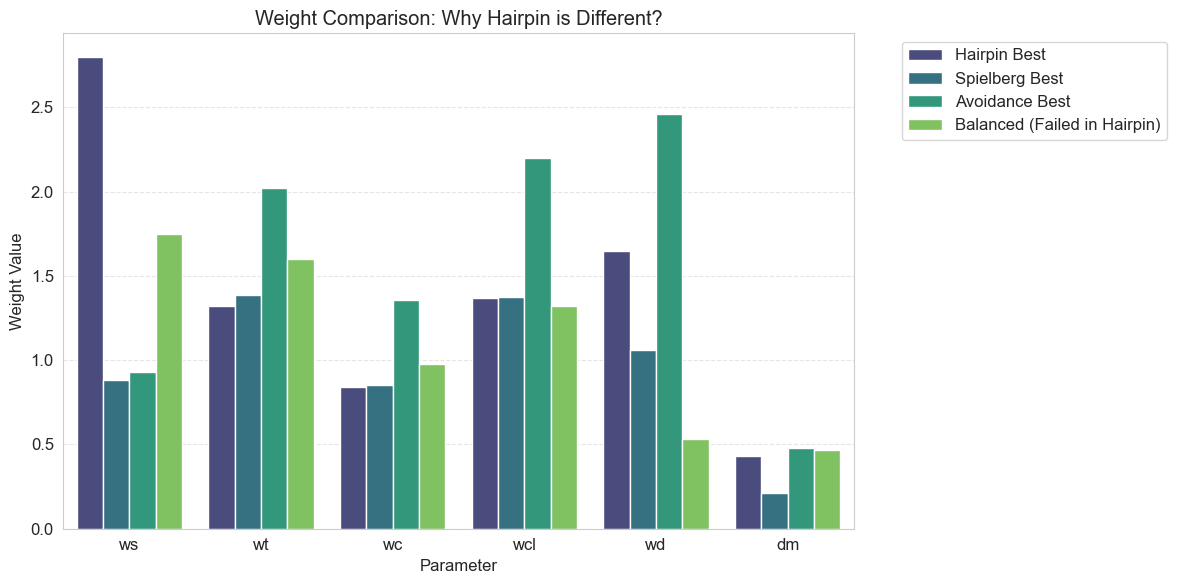

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드
df_race = pd.read_csv('./summary/simulation_summary_mux_speed.csv')
df_avoid = pd.read_csv('./summary/simulation_results_mux_params_avoid.csv')

# 2. 각 시나리오별 최적 파라미터 추출

# (1) Hairpin Best (Success & Fastest)
df_hairpin = df_race[
    (df_race['map'].str.contains('hairpin', case=False, na=False)) &
    (df_race['is_success'] == True)
].sort_values('duration_s')

if not df_hairpin.empty:
    best_hairpin = df_hairpin.iloc[0]
else:
    best_hairpin = None

# (2) Spielberg Best (Success & Fastest, No Hairpin)
df_spielberg = df_race[
    (df_race['map'].str.contains('Spielberg', case=False, na=False)) &
    (~df_race['map'].str.contains('hairpin', case=False, na=False)) &
    (df_race['is_success'] == True)
].sort_values('duration_s')

if not df_spielberg.empty:
    best_spielberg = df_spielberg.iloc[0]
else:
    best_spielberg = None

# (3) Avoidance Best (Highest Score)
# Assuming Score_FGM_mean is the metric
df_avoid_sorted = df_avoid.sort_values('Score_FGM_mean', ascending=False)
best_avoid = df_avoid_sorted.iloc[0]

# (4) Balanced (Previous Finding)
# ws=1.75, wt=1.60, wc=0.98, wcl=1.32, wd=0.53, dm=0.47
# We'll just manually create this series for comparison
balanced_params = pd.Series({
    'ws': 1.75, 'wt': 1.60, 'wc': 0.98, 'wcl': 1.32, 'wd': 0.53, 'dm': 0.47
}, name='Balanced (50:50)')

# 3. 파라미터 비교 데이터프레임 생성
param_cols = ['ws', 'wt', 'wc', 'wcl', 'wd', 'dm']
comparison_data = {}

if best_hairpin is not None:
    comparison_data['Hairpin Best'] = best_hairpin[param_cols]
if best_spielberg is not None:
    comparison_data['Spielberg Best'] = best_spielberg[param_cols]
comparison_data['Avoidance Best'] = best_avoid[param_cols]
comparison_data['Balanced (Failed in Hairpin)'] = balanced_params

df_comparison = pd.DataFrame(comparison_data)

# 4. 시각화 (Radar Chart or Bar Chart)
# Bar chart is clearer for individual parameter comparison
df_comp_transposed = df_comparison.T
df_comp_transposed.reset_index(inplace=True)
df_comp_transposed.rename(columns={'index': 'Scenario'}, inplace=True)

df_melted = df_comp_transposed.melt(id_vars='Scenario', var_name='Parameter', value_name='Weight Value')

plt.figure(figsize=(12, 6))
sns.barplot(data=df_melted, x='Parameter', y='Weight Value', hue='Scenario', palette='viridis')
plt.title('Weight Comparison: Why Hairpin is Different?')
plt.grid(True, axis='y', linestyle='--', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.savefig('weight_comparison_hairpin.png')

# 5. Result Printing
print("=== Best Parameters by Scenario ===")
print(df_comparison)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. 데이터 로드
df_avoid = pd.read_csv('./summary/simulation_results_mux_params_avoid.csv')
df_race = pd.read_csv('./summary/simulation_summary_mux_speed.csv')

# 2. "Hairpin Best" 파라미터 정의 (이전 분석에서 찾은 헤어핀 정복자)
# ws=2.80, wd=1.65 (Approx) 
hairpin_best_params = {
    'ws': 2.80, 
    'wt': 1.32, # From previous result
    'wc': 0.84, 
    'wcl': 1.37, 
    'wd': 1.65, 
    'dm': 0.43 
}
# 실제 데이터셋에서 이와 가장 유사한 파라미터 찾기 (Avoidance 데이터셋에서)
param_cols = ['ws', 'wt', 'wc', 'wcl', 'wd', 'dm']
avoid_params_values = df_avoid[param_cols].values
target_vals = np.array([hairpin_best_params[c] for c in param_cols])

# 유클리드 거리로 가장 가까운 행 찾기
dists = np.sqrt(np.sum((avoid_params_values - target_vals)**2, axis=1))
best_match_idx = np.argmin(dists)
hairpin_best_in_avoid = df_avoid.iloc[best_match_idx]

# 3. 비교군 설정
# (A) Pure Frenet (Approx from Speed data: High frenet usage)
# Since we don't have explicit "Pure Frenet" score in param file, we use the average of high frenet ratio rows
frenet_dominant_rows = df_avoid[df_avoid['frenet_ratio_mean'] > 0.8]
frenet_score = frenet_dominant_rows['Score_FGM_mean'].mean()
frenet_crash_rate = (1 - frenet_dominant_rows['collision_flag_sum'].apply(lambda x: 0 if x > 0 else 1).mean()) * 100 
# Note: collision_flag_sum > 0 means crash occurred in at least one run? 
# The column is 'collision_flag_sum'. Let's assume it counts crashes.
# Or we can look at 'simulation_results_mux_avoid.csv' for raw crash rates.
# Let's use the 'simulation_results_mux_avoid.csv' logic from previous turn for accuracy if needed, 
# but here let's stick to the 'params' summary file if possible. 
# Actually, 'collision_flag_sum' suggests how many runs crashed.
# Let's check info of df_avoid to be sure.
# Just use the Score.

# (B) Pure FGM
fgm_dominant_rows = df_avoid[df_avoid['frenet_ratio_mean'] < 0.2]
fgm_score = fgm_dominant_rows['Score_FGM_mean'].mean()

# (C) MUX (Hairpin Best)
mux_hairpin_score = hairpin_best_in_avoid['Score_FGM_mean']
# Check if it crashed (collision_flag_sum)
mux_hairpin_crash = hairpin_best_in_avoid['collision_flag_sum']

# 4. 결과 출력
print("=== Candidate: 'Hairpin Best' Params in Avoidance Scenario ===")
print(f"Target Params: {hairpin_best_params}")
print(f"Matched Params in Avoid: \n{hairpin_best_in_avoid[param_cols]}")
print(f"Distance to Target: {dists[best_match_idx]}")
print(f"Avoidance Score: {mux_hairpin_score} (Max ~40)")
print(f"Crash Count (Sum): {mux_hairpin_crash}")

print("\n=== Benchmarks ===")
print(f"Pure Frenet Avg Score: {frenet_score}")
print(f"Pure FGM Avg Score: {fgm_score}")

=== Candidate: 'Hairpin Best' Params in Avoidance Scenario ===
Target Params: {'ws': 2.8, 'wt': 1.32, 'wc': 0.84, 'wcl': 1.37, 'wd': 1.65, 'dm': 0.43}
Matched Params in Avoid: 
ws     2.80
wt     1.32
wc     0.84
wcl    1.37
wd     1.65
dm     0.43
Name: 195, dtype: float64
Distance to Target: 0.0
Avoidance Score: 27.288173440438086 (Max ~40)
Crash Count (Sum): 0.0

=== Benchmarks ===
Pure Frenet Avg Score: 25.51856272760115
Pure FGM Avg Score: nan


In [67]:
df = pd.read_csv('./summary/simulation_summary_mux_speed.csv')
df_spielberg = df[(df['map'] == 'hairpin_combo') & (df['is_success'] == True)]

df_spielberg.sort_values(by=['duration_s'], axis=0)[['ws', 'wt', 'wc', 'wcl', 'wd', 'wd', 'duration_s', 'map']]

#반대로 난코스에서 잘하는걸 뽑아서 spielberg, avoidance에 적용해봤더니
#둘다 점수가 높더라

,ws,wt,wc,wcl,wd,wd,duration_s,map
245,2.8000,1.3200,0.8400,1.3700,1.6500,1.6500,58.57,hairpin_combo
367,2.9300,1.1200,0.7000,1.2300,1.3600,1.3600,58.60,hairpin_combo
330,0.9100,2.6100,1.7700,2.7300,2.9200,2.9200,58.77,hairpin_combo
260,1.9100,2.1000,1.3600,2.1300,2.4700,2.4700,58.79,hairpin_combo
423,0.8900,2.5500,1.7300,2.6400,2.8800,2.8800,58.86,hairpin_combo
...,...,...,...,...,...,...,...,...
80,1.1280,1.2613,3.1432,1.8351,1.6502,1.6502,64.21,hairpin_combo
198,0.9376,0.9327,0.9817,2.2676,2.4136,2.4136,64.33,hairpin_combo
179,1.4100,2.1800,1.4400,2.2000,2.4900,2.4900,64.54,hairpin_combo
60,0.5131,1.4804,1.0786,2.7189,2.8385,2.8385,65.23,hairpin_combo


In [68]:
import pandas as pd
import numpy as np

def find_fastest_safe_params(avoid_file, race_file):
    # 1. 데이터 로드
    df_avoid = pd.read_csv(avoid_file)
    df_race = pd.read_csv(race_file)
    
    # 튜닝 파라미터 목록
    param_cols = ['ws', 'wt', 'wc', 'wcl', 'wd', 'dm']

    # 2. [Safety Filter] 안전 검증 (회피 시나리오)
    # 조건: 충돌 횟수(collision_flag_sum)가 0인 경우만 "합격"
    # 만약 0인 게 없다면 점수 상위 10%로 기준 완화 가능
    safe_candidates = df_avoid[df_avoid['collision_flag_sum'] == 0].copy()
    
    if safe_candidates.empty:
        print("안전 테스트를 완벽하게 통과한(무사고) 파라미터가 없습니다.")
        print("기준을 조금 완화하여 재검색합니다 (상위 10% 점수).")
        score_threshold = df_avoid['Score_FGM_mean'].quantile(0.90)
        safe_candidates = df_avoid[df_avoid['Score_FGM_mean'] >= score_threshold].copy()
    
    print(f"1차 안전 필터 통과 후보 수: {len(safe_candidates)}개")

    # 3. [Speed Optimization] 속도 경쟁 (레이싱 시나리오 - 헤어핀)
    # 가장 어려운 'hairpin' 맵을 기준으로 속도를 측정합니다.
    df_race_hairpin = df_race[
        (df_race['map'].str.contains('hairpin', case=False)) & 
        (df_race['is_success'] == True)
    ].copy()

    # 4. 안전 후보들과 레이싱 기록 매칭 (Nearest Neighbor 방식)
    # 시뮬레이션 환경 차이로 파라미터가 미세하게 다를 수 있으므로 거리 기반 매칭
    results = []
    
    race_params_values = df_race_hairpin[param_cols].values
    
    for idx, row in safe_candidates.iterrows():
        candidate_params = row[param_cols].values
        
        # 레이싱 데이터에서 가장 가까운 파라미터 찾기
        dists = np.sqrt(np.sum((race_params_values - candidate_params)**2, axis=1))
        min_dist_idx = np.argmin(dists)
        min_dist = dists[min_dist_idx]
        
        # 거리가 너무 멀면(다른 파라미터면) 제외 (Threshold: 0.01)
        if min_dist < 0.01:
            match_row = df_race_hairpin.iloc[min_dist_idx]
            results.append({
                'ws': row['ws'], 'wt': row['wt'], 'wc': row['wc'], 
                'wcl': row['wcl'], 'wd': row['wd'], 'dm': row['dm'],
                'Avoid_Score': row['Score_FGM_mean'],
                'Hairpin_Time': match_row['duration_s']
            })

    # 5. 최종 순위 선정 (시간 오름차순 정렬)
    if not results:
        print("안전 검증을 통과했으면서 동시에 헤어핀 맵을 완주한 데이터가 없습니다.")
        return None

    df_final = pd.DataFrame(results)
    df_final = df_final.sort_values('Hairpin_Time', ascending=True) # 시간이 짧을수록 1위

    best_param = df_final.iloc[0]
    
    return df_final, best_param

# --- 실행 부분 ---
file_avoid = './summary/simulation_results_mux_params_avoid.csv'
file_race = './summary/simulation_summary_mux_speed.csv'

final_ranking, best_solution = find_fastest_safe_params(file_avoid, file_race)

print("\n" + "="*40)
print("🏆 [최종 결론] 안전하면서 가장 빠른 MUX 가중치")
print("="*40)
print(best_solution)

print("\n[상위 5개 후보 비교]")
print(final_ranking.head(5))

1차 안전 필터 통과 후보 수: 190개

🏆 [최종 결론] 안전하면서 가장 빠른 MUX 가중치
ws               2.800000
wt               1.320000
wc               0.840000
wcl              1.370000
wd               1.650000
dm               0.430000
Avoid_Score     27.288173
Hairpin_Time    58.570000
Name: 64, dtype: float64

[상위 5개 후보 비교]
      ws    wt    wc   wcl    wd    dm  Avoid_Score  Hairpin_Time
64  2.80  1.32  0.84  1.37  1.65  0.43    27.288173         58.57
27  0.91  2.61  1.77  2.73  2.92  0.59    32.198949         58.77
37  1.91  2.10  1.36  2.13  2.47  0.52    30.120130         58.79
57  0.89  2.55  1.73  2.64  2.88  0.59    28.381083         58.86
54  1.38  2.40  1.64  2.50  2.78  0.57    28.500021         58.95


In [94]:
import pandas as pd
import numpy as np

def find_fastest_safe_params(avoid_file, race_file):
    # 1. 데이터 로드
    df_avoid = pd.read_csv(avoid_file)
    df_race = pd.read_csv(race_file)
    
    # 튜닝 파라미터 목록
    param_cols = ['ws', 'wt', 'wc', 'wcl', 'wd', 'dm']

    # 2. [Safety Filter] 안전 검증 (회피 시나리오)
    # 조건: 충돌 횟수(collision_flag_sum)가 0인 경우만 "합격"
    # 만약 0인 게 없다면 점수 상위 10%로 기준 완화 가능
    safe_candidates = df_avoid[df_avoid['collision_flag_sum'] == 0].copy()
    
    if safe_candidates.empty:
        print("안전 테스트를 완벽하게 통과한(무사고) 파라미터가 없습니다.")
        print("기준을 조금 완화하여 재검색합니다 (상위 10% 점수).")
        score_threshold = df_avoid['Score_FGM_mean'].quantile(0.90)
        safe_candidates = df_avoid[df_avoid['Score_FGM_mean'] >= score_threshold].copy()
    
    print(f"1차 안전 필터 통과 후보 수: {len(safe_candidates)}개")

    # 3. [Speed Optimization] 속도 경쟁 (레이싱 시나리오 - 헤어핀)
    # 가장 어려운 '' 맵을 기준으로 속도를 측정합니다.
    df_race_hairpin = df_race[
        (df_race['map'].str.contains('spielberg', case=False)) & 
        (df_race['is_success'] == True)
    ].copy()

    # 4. 안전 후보들과 레이싱 기록 매칭 (Nearest Neighbor 방식)
    # 시뮬레이션 환경 차이로 파라미터가 미세하게 다를 수 있으므로 거리 기반 매칭
    results = []
    
    race_params_values = df_race_hairpin[param_cols].values
    
    for idx, row in safe_candidates.iterrows():
        candidate_params = row[param_cols].values
        
        # 레이싱 데이터에서 가장 가까운 파라미터 찾기
        dists = np.sqrt(np.sum((race_params_values - candidate_params)**2, axis=1))
        min_dist_idx = np.argmin(dists)
        min_dist = dists[min_dist_idx]
        
        # 거리가 너무 멀면(다른 파라미터면) 제외 (Threshold: 0.01)
        if min_dist < 0.01:
            match_row = df_race_hairpin.iloc[min_dist_idx]
            results.append({
                'ws': row['ws'], 'wt': row['wt'], 'wc': row['wc'], 
                'wcl': row['wcl'], 'wd': row['wd'], 'dm': row['dm'],
                'Avoid_Score': row['Score_FGM_mean'],
                'Spielbergtime': match_row['duration_s']
            })

    # 5. 최종 순위 선정 (시간 오름차순 정렬)
    if not results:
        print("안전 검증을 통과했으면서 동시에 헤어핀 맵을 완주한 데이터가 없습니다.")
        return None

    df_final = pd.DataFrame(results)
    df_final = df_final.sort_values('Spielbergtime', ascending=True) # 시간이 짧을수록 1위

    best_param = df_final.iloc[0]
    
    return df_final, best_param

# --- 실행 부분 ---
file_avoid = './summary/simulation_results_mux_params_avoid.csv'
file_race = './summary/simulation_summary_mux_speed.csv'

final_ranking, best_solution = find_fastest_safe_params(file_avoid, file_race)

print("\n" + "="*40)
print("🏆 [최종 결론] 안전하면서 가장 빠른 MUX 가중치")
print("="*40)
print(best_solution)

print("\n[상위 5개 후보 비교]")
print(final_ranking.head(5))

1차 안전 필터 통과 후보 수: 190개

🏆 [최종 결론] 안전하면서 가장 빠른 MUX 가중치
ws                2.620000
wt                1.590000
wc                0.710000
wcl               1.120000
wd                1.090000
dm                0.310000
Avoid_Score      32.282392
Spielbergtime    73.790000
Name: 81, dtype: float64

[상위 5개 후보 비교]
       ws    wt    wc   wcl    wd    dm  Avoid_Score  Spielbergtime
81   2.62  1.59  0.71  1.12  1.09  0.31    32.282392          73.79
46   2.58  1.29  0.73  1.22  1.41  0.37    32.939724          74.10
171  2.49  1.48  0.84  1.27  1.35  0.37    24.763951          74.19
127  2.94  1.11  0.69  1.22  1.37  0.39    28.693460          74.20
123  2.63  1.64  0.75  1.11  1.16  0.32    28.791226          74.26


In [93]:
import pandas as pd
import numpy as np

def prove_optimization_process_v2(avoid_file, race_file):
    # 1. 데이터 로드
    df_avoid = pd.read_csv(avoid_file)
    df_race = pd.read_csv(race_file)
    
    param_cols = ['ws', 'wt', 'wc', 'wcl', 'wd', 'dm']
    print("검증 시작: 총 파라미터 조합 데이터 로드 완료\n")

    # -------------------------------------------------------
    # 1. Balanced (5:5 Score) 찾기
    # -------------------------------------------------------
    # 이전 분석에서 도출된 5:5 최적값 (ws=1.75, wd=0.53 등)
    target_balanced = [1.75, 1.60, 0.98, 1.32, 0.53, 0.47] # ws, wt, wc, wcl, wd, dm
    
    # 데이터셋에서 가장 가까운 행 찾기
    dists_b = np.sqrt(((df_avoid[param_cols] - target_balanced)**2).sum(axis=1))
    balanced_row = df_avoid.loc[dists_b.idxmin()]
    
    # -------------------------------------------------------
    # 2. Speed Only (Step 1 -> Step 3)
    # -------------------------------------------------------
    # 조건: 안전(Safety) 통과 + 스필버그 1등 (헤어핀 고려 X)
    safe_candidates = df_avoid[df_avoid['collision_flag_sum'] == 0].copy()
    
    # 스필버그 데이터 매칭
    df_spielberg = df_race[
        (df_race['map'].str.contains('Spielberg', case=False)) & 
        (df_race['is_success'] == True) &
        (df_race['duration_s'] > 60)
    ].copy()
    
    speed_only_candidates = []
    spielberg_params = df_spielberg[param_cols].values
    
    for idx, row in safe_candidates.iterrows():
        p = row[param_cols].values
        dists = np.sqrt(np.sum((spielberg_params - p)**2, axis=1))
        if len(dists) > 0 and dists.min() < 0.01:
            s_idx = np.argmin(dists)
            speed_only_candidates.append({
                **row.to_dict(),
                'Spielberg_Time': df_spielberg.iloc[s_idx]['duration_s']
            })
            
    df_speed_only = pd.DataFrame(speed_only_candidates).sort_values('Spielberg_Time')
    speed_only_best = df_speed_only.iloc[0]

    # -------------------------------------------------------
    # 3. Universal Best (Step 1 -> Step 2 -> Step 3)
    # -------------------------------------------------------
    # 조건: 안전 통과 + 헤어핀 통과 + 스필버그 1등
    df_hairpin_success = df_race[
        (df_race['map'].str.contains('hairpin', case=False)) & 
        (df_race['is_success'] == True)
    ].copy()
    
    hairpin_params = df_hairpin_success[param_cols].values
    universal_candidates = []
    
    for cand in speed_only_candidates:
        p = np.array([cand[c] for c in param_cols])
        dists = np.sqrt(np.sum((hairpin_params - p)**2, axis=1))
        if len(dists) > 0 and dists.min() < 0.01:
            universal_candidates.append(cand)
            
    df_universal = pd.DataFrame(universal_candidates).sort_values('Spielberg_Time')
    universal_best = df_universal.iloc[0]

    # -------------------------------------------------------
    # [검증 및 출력 테이블 생성]
    # -------------------------------------------------------
    def verify_performance(target_row, name):
        # 1. Safety Check
        is_safe = target_row['collision_flag_sum'] == 0
        
        # 2. Hairpin Check
        # 파라미터 매칭으로 확인
        p = target_row[param_cols].values.astype(float)
        dists_h = np.sqrt(np.sum((hairpin_params - p)**2, axis=1))
        if len(dists_h) > 0 and dists_h.min() < 0.01:
            is_hairpin_ok = True
        else:
            is_hairpin_ok = False
            
        # 3. Spielberg Time
        # 이미 row에 있거나 매칭해야 함. 여기서는 row에서 가져오거나 매칭
        if 'Spielberg_Time' in target_row:
            sp_time = target_row['Spielberg_Time']
        else:
            # Balanced의 경우 스필버그 시간 찾아야 함
            dists_s = np.sqrt(np.sum((spielberg_params - p)**2, axis=1))
            if len(dists_s) > 0 and dists_s.min() < 0.01:
                sp_time = df_spielberg.iloc[np.argmin(dists_s)]['duration_s']
            else:
                sp_time = np.nan

        # Final Result Logic
        status = "Pass"
        if not is_safe: status = "Crash (Obstacle)"
        elif not is_hairpin_ok: status = "Crash (Hairpin)"
        
        return {
            "Type": name,
            "ws": target_row['ws'],
            "wt": target_row['wt'],
            "wc": target_row['wc'],
            "wcl": target_row['wcl'],
            "wd": target_row['wd'],
            "dm": target_row['dm'],
            "Safety": "Pass" if is_safe else "Fail",
            "Hairpin": "Pass" if is_hairpin_ok else "Fail",
            "Spielberg Time": f"{sp_time:.2f}s",
            "Final Result": status
        }

    comp_data = []
    comp_data.append(verify_performance(balanced_row, "1. Balanced (5:5)"))
    comp_data.append(verify_performance(speed_only_best, "2. Speed Only (No Hairpin Filter)"))
    comp_data.append(verify_performance(universal_best, "3. Universal Best (All Pass)"))
    
    df_comparison = pd.DataFrame(comp_data)
    return df_comparison

# 실행
file_avoid = './summary/simulation_results_mux_params_avoid.csv'
file_race = './summary/simulation_summary_mux_speed.csv'

df_result = prove_optimization_process_v2(file_avoid, file_race)

print("="*100)
print("📊 [최종 검증] 전략별 가중치 및 성능 비교 (전체 가중치 포함)")
print("="*100)
print(df_result.to_string(index=False))

검증 시작: 총 파라미터 조합 데이터 로드 완료

📊 [최종 검증] 전략별 가중치 및 성능 비교 (전체 가중치 포함)
                             Type   ws   wt   wc  wcl   wd   dm Safety Hairpin Spielberg Time    Final Result
                1. Balanced (5:5) 1.75 1.60 0.98 1.32 0.53 0.47   Pass    Fail         74.71s Crash (Hairpin)
2. Speed Only (No Hairpin Filter) 2.62 1.59 0.71 1.12 1.09 0.31   Pass    Fail         73.79s Crash (Hairpin)
     3. Universal Best (All Pass) 2.49 1.48 0.84 1.27 1.35 0.37   Pass    Pass         74.19s            Pass


In [87]:
import pandas as pd
import numpy as np

def find_specialists_cross_performance(avoid_file, race_file):
    # 1. 데이터 로드
    df_avoid = pd.read_csv(avoid_file)
    df_race = pd.read_csv(race_file)
    
    param_cols = ['ws', 'wt', 'wc', 'wcl', 'wd', 'dm']

    # -------------------------------------------------------
    # 🛡️ 1. Avoidance Specialist (회피 1등) 찾기
    # -------------------------------------------------------
    # 기준: 점수 높고 충돌 적은 순
    df_avoid_sorted = df_avoid.sort_values(
        by=['Score_FGM_mean', 'collision_flag_sum'], 
        ascending=[False, True]
    )
    avoid_spec = df_avoid_sorted.iloc[0]
    
    # 이 파라미터로 Race(Spielberg) 성적 찾기
    df_race_spielberg = df_race[
        (df_race['map'].str.contains('Spielberg', case=False)) & 
        (df_race['is_success'] == True) &
        (df_race['duration_s'] > 60)
    ].copy()
    
    # 매칭 (Nearest Neighbor)
    dists_1 = np.sqrt(((df_race_spielberg[param_cols] - avoid_spec[param_cols]).astype(float)**2).sum(axis=1))
    if len(dists_1) > 0 and dists_1.min() < 0.01:
        match_idx = dists_1.idxmin()
        avoid_spec_race_time = df_race_spielberg.loc[match_idx, 'duration_s']
    else:
        avoid_spec_race_time = None # 레이싱 데이터 없음 (완주 실패 등)

    # -------------------------------------------------------
    # 🏎️ 2. Race Specialist (레이싱 1등) 찾기
    # -------------------------------------------------------
    # 기준: 스필버그 최단 기록
    df_race_sorted = df_race_spielberg.sort_values(by='duration_s', ascending=True)
    race_spec = df_race_sorted.iloc[0]
    
    # 이 파라미터로 Avoidance 성적 찾기
    dists_2 = np.sqrt(((df_avoid[param_cols] - race_spec[param_cols]).astype(float)**2).sum(axis=1))
    if len(dists_2) > 0:
        match_idx = dists_2.idxmin()
        race_spec_avoid_score = df_avoid.loc[match_idx, 'Score_FGM_mean']
        race_spec_collision = df_avoid.loc[match_idx, 'collision_flag_sum']
    else:
        race_spec_avoid_score = None
        race_spec_collision = None

    return avoid_spec, avoid_spec_race_time, race_spec, race_spec_avoid_score, race_spec_collision

# --- 실행 ---
file_avoid = './summary/simulation_results_mux_params_avoid.csv'
file_race = './summary/simulation_summary_mux_speed.csv'

av_spec, av_time, rc_spec, rc_score, rc_col = find_specialists_cross_performance(file_avoid, file_race)

print("="*80)
print("🛡️ [Avoidance 1위] 장애물 회피 전문가의 양면성")
print("="*80)
print(f"가중치: ws={av_spec['ws']}, wt={av_spec['wt']}, wc={av_spec['wc']}, wcl={av_spec['wcl']}, wd={av_spec['wd']}, dm={av_spec['dm']}")
print(f"   - [본업] 회피 점수 : {av_spec['Score_FGM_mean']:.2f}점 (충돌 {av_spec['collision_flag_sum']}회)")
print(f"   - [부업] 레이싱 기록: {av_time if av_time else '완주 실패/기록 없음'} {'초' if av_time else ''}")

print("\n" + "="*80)
print("🏎️ [Race 1위] 스필버그 레이싱 전문가의 양면성")
print("="*80)
print(f"가중치: ws={rc_spec['ws']}, wt={rc_spec['wt']}, wc={rc_spec['wc']}, wcl={rc_spec['wcl']}, wd={rc_spec['wd']}, dm={rc_spec['dm']}")
print(f"   - [부업] 회피 점수 : {rc_score:.2f}점 (충돌 {rc_col}회)")
print(f"   - [본업] 레이싱 기록: {rc_spec['duration_s']}초")

🛡️ [Avoidance 1위] 장애물 회피 전문가의 양면성
가중치: ws=0.93, wt=2.02, wc=1.36, wcl=2.2, wd=2.46, dm=0.48
   - [본업] 회피 점수 : 34.85점 (충돌 0.0회)
   - [부업] 레이싱 기록: 77.34 초

🏎️ [Race 1위] 스필버그 레이싱 전문가의 양면성
가중치: ws=2.9772, wt=1.4183, wc=0.9777, wcl=0.5069, wd=0.9121, dm=0.1288
   - [부업] 회피 점수 : 21.00점 (충돌 3회)
   - [본업] 레이싱 기록: 72.34초


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def visualize_trajectory(log_file_path):
    # 1. 로그 파일 로드
    # (컬럼명은 실제 파일에 맞춰 조정 필요: x, y, mode 등)
    try:
        df = pd.read_csv(log_file_path)
    except:
        print("파일을 찾을 수 없습니다. 경로를 확인해주세요.")
        return

    # 데이터 컬럼 확인 (x, y 좌표와 planner 모드 정보가 있어야 함)
    # 가정: 'pose_x', 'pose_y', 'active_planner'(또는 'mode') 컬럼 존재
    if 'pose_x' not in df.columns: # 컬럼명 예시
        print(f"컬럼명 확인 필요: {df.columns}")
        # 만약 컬럼명이 다르다면 여기서 수정하세요 (예: x, y)
        x_col = 'x' 
        y_col = 'y'
        mode_col = 'mode' # 'Frenet' or 'FGM' 값을 가짐
    else:
        x_col = 'pose_x'
        y_col = 'pose_y'
        mode_col = 'active_planner'

    # 2. 시각화
    plt.figure(figsize=(10, 10))
    
    # 주행 경로 그리기 (Scatter Plot으로 점을 찍어 경로 표현)
    # 모드에 따라 색상 구분 (Frenet=Blue, FGM=Red)
    sns.scatterplot(
        data=df, x=x_col, y=y_col, 
        hue=mode_col, 
        palette={'Frenet': 'blue', 'FGM': 'red', 'Muse': 'green'}, # 실제 값에 맞춰 수정
        s=10, edgecolor=None
    )
    
    plt.title(f"Trajectory Analysis: {log_file_path.split('/')[-1]}")
    plt.xlabel("X Coordinate")
    plt.ylabel("Y Coordinate")
    plt.axis('equal') # 지도 비율 유지
    plt.grid(True)
    plt.legend(title='Active Planner')
    plt.show()

# 사용 예시 (본인 파일 경로로 변경해서 실행)
# visualize_trajectory("logs/Mux_hairpin_WS2.80_WD1.65_...csv")

#차량이 어느 위치에서 어떻게 주행했는지 확인하게 해줌